# 🛡️ PrédiSinistre — Détection de Fraude Assurantielle
## Rendu 1 : Exploration, Data Visualisation & Pre-processing

---

| Champ              | Détail                                              |
|--------------------|-----------------------------------------------------|
| **Cursus**         | Data Scientist — DataScientest                      |
| **Difficulté**     | 6 / 10                                              |
| **Dataset**        | `insurance_claims.csv` (1 000 lignes × 40 colonnes) |
| **Variable cible** | `fraud_reported` (Y = fraude / N = non-fraude)      |
| **Objectif**       | Détecter automatiquement les sinistres frauduleux   |

---

## 📋 Plan du notebook

1. [Imports & Configuration](#1)
2. [Chargement et première inspection](#2)
3. [Analyse univariée](#3)
4. [Visualisation — 6 graphiques commentés](#4)
5. [Nettoyage et préparation du dataset](#5)
6. [Encodage et Feature Engineering](#6)
7. [Export du dataset propre](#7)
8. [Modèles de base (Baseline)](#8)
9. [Interprétation et perspectives](#9)

---
## 1. Imports & Configuration <a id='1'></a>

On importe toutes les bibliothèques nécessaires en une seule cellule, conformément aux bonnes pratiques :
- **pandas / numpy** : manipulation et calcul sur données tabulaires
- **matplotlib / seaborn** : visualisation
- **sklearn** : prétraitement, modèles et évaluation

On fixe également les graines aléatoires (`RANDOM_STATE`) pour garantir la **reproductibilité** des résultats.

In [1]:
# ─────────────────────────────────────────────────────────────────
# BLOC 1 — IMPORTS & CONFIGURATION GLOBALE
# ─────────────────────────────────────────────────────────────────

# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Prétraitement & sélection de features
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# Modèles de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier  # modèle naïf de référence

# Métriques d'évaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score
)

# Utilitaires
import warnings
warnings.filterwarnings('ignore')  # masquer les avertissements non critiques

# ── Constantes de configuration ──────────────────────────────────
RANDOM_STATE = 42          # graine pour la reproductibilité
TEST_SIZE    = 0.20        # proportion du jeu de test
DATA_PATH    = 'insurance_claims.csv'  # chemin vers le dataset brut
OUTPUT_PATH  = 'insurance_claims_clean.csv'  # chemin de sortie

# ── Palette de couleurs cohérente dans tout le notebook ──────────
COLOR_NON_FRAUD = '#2E86AB'   # bleu  → sinistres légitimes
COLOR_FRAUD     = '#E84855'   # rouge → sinistres frauduleux
PALETTE_GENERAL = ['#2E86AB', '#E84855', '#3BB273', '#F9C74F', '#9B5DE5']

# ── Style global des graphiques ──────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi'      : 120,
    'font.family'     : 'DejaVu Sans',
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'legend.fontsize' : 10,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
})

print('✅ Imports et configuration terminés.')

✅ Imports et configuration terminés.


---
## 2. Chargement et première inspection du dataset <a id='2'></a>

Cette étape vise à répondre à trois questions fondamentales :
1. **Quelle est la structure du dataset ?** (dimensions, types de colonnes)
2. **Y a-t-il des données manquantes ?** (NaN natifs, valeurs encodées '?')
3. **Quelle est la distribution de la variable cible ?** (déséquilibre de classes)

> 📌 **Règle méthodologique** : on n'effectue AUCUNE transformation à ce stade — on observe uniquement.

In [2]:
# ─────────────────────────────────────────────────────────────────
# BLOC 2.1 — CHARGEMENT DU DATASET
# ─────────────────────────────────────────────────────────────────

df = pd.read_csv("../data/raw/insurance_claims.csv")

# Affichage des dimensions et des premières lignes du dataset
print('=' * 60)
print(f'  Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print('=' * 60)

df.head()

  Dimensions : 1000 lignes × 40 colonnes


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [3]:
# ─────────────────────────────────────────────────────────────────
# BLOC 2.2 — TYPES ET VALEURS MANQUANTES
# ─────────────────────────────────────────────────────────────────

# Résumé des types de données : distinguer variables numériques / catégorielles
dtype_summary = pd.DataFrame({
    'Type'           : df.dtypes,
    'Valeurs_nulles' : df.isnull().sum(),
    '% Nulles'       : (df.isnull().sum() / len(df) * 100).round(2),
    'Nb_uniques'     : df.nunique(),
})

# Détection des colonnes contenant des '?' (valeurs manquantes masquées)
question_mark_counts = {}
#for col in df.select_dtypes(include=['object', 'str']).columns: # ancienne version
for col in df.select_dtypes(include=[np.dtype("O")]).columns:
    count = (df[col] == '?').sum()
    if count > 0:
        question_mark_counts[col] = count


dtype_summary['Nb_points_interrogation'] = 0
for col, count in question_mark_counts.items():
    dtype_summary.loc[col, 'Nb_points_interrogation'] = count

# Affichage du résumé des types et des valeurs manquantes
print('─── Résumé des colonnes ───────────────────────────────────')
print(dtype_summary.to_string())
print()
print(f'⚠️  Colonnes avec des points d\'interrogation : {list(question_mark_counts.keys())}')

─── Résumé des colonnes ───────────────────────────────────
                                Type  Valeurs_nulles  % Nulles  Nb_uniques  Nb_points_interrogation
months_as_customer             int64               0       0.0         391                        0
age                            int64               0       0.0          46                        0
policy_number                  int64               0       0.0        1000                        0
policy_bind_date              object               0       0.0         951                        0
policy_state                  object               0       0.0           3                        0
policy_csl                    object               0       0.0           3                        0
policy_deductable              int64               0       0.0           3                        0
policy_annual_premium        float64               0       0.0         991                        0
umbrella_limit                 int64    

In [4]:
# ─────────────────────────────────────────────────────────────────
# BLOC 2.3 — DISTRIBUTION DE LA VARIABLE CIBLE
# ─────────────────────────────────────────────────────────────────

# Comptage et taux par classe
target_counts = df['fraud_reported'].value_counts()
target_pct    = df['fraud_reported'].value_counts(normalize=True) * 100

print('─── Variable cible : fraud_reported ───────────────────────')
print(f'  Non-fraude (N) : {target_counts["N"]:>5} observations  ({target_pct["N"]:.1f} %)') # alignement à droite pour les nombres
print(f'  Fraude     (Y) : {target_counts["Y"]:>5} observations  ({target_pct["Y"]:.1f} %)')
print(f'  Ratio déséquilibre : {target_counts["N"] / target_counts["Y"]:.2f}:1')
print()
print('💡 Conclusion : déséquilibre modéré (3:1). On privilégiera')
print('   le ROC-AUC et le F1-score plutôt que l\'accuracy globale.')

─── Variable cible : fraud_reported ───────────────────────
  Non-fraude (N) :   753 observations  (75.3 %)
  Fraude     (Y) :   247 observations  (24.7 %)
  Ratio déséquilibre : 3.05:1

💡 Conclusion : déséquilibre modéré (3:1). On privilégiera
   le ROC-AUC et le F1-score plutôt que l'accuracy globale.


In [5]:
# ─────────────────────────────────────────────────────────────────
# BLOC 2.4 — STATISTIQUES DESCRIPTIVES DES VARIABLES NUMÉRIQUES
# ─────────────────────────────────────────────────────────────────

# describe() donne : count, mean, std, min, quartiles, max
# On transpose pour une meilleure lisibilité
num_stats = df.select_dtypes(include='number').describe().T

# Ajout d'une colonne d'asymétrie (skewness) : >0 = queue à droite, <0 = queue à gauche
num_stats['skewness'] = df.select_dtypes(include='number').skew().round(3)

print('─── Statistiques descriptives — Variables numériques ───────')
num_stats.round(2)

─── Statistiques descriptives — Variables numériques ───────


,count,mean,std,min,25%,50%,75%,max,skewness
months_as_customer,1000.0,203.95,115.11,0.00,115.75,199.5,276.25,479.00,0.36
age,1000.0,38.95,9.14,19.00,32.00,38.0,44.00,64.00,0.48
policy_number,1000.0,546238.65,257063.01,100804.00,335980.25,533135.0,759099.75,999435.00,0.04
policy_deductable,1000.0,1136.00,611.86,500.00,500.00,1000.0,2000.00,2000.00,0.48
policy_annual_premium,1000.0,1256.41,244.17,433.33,1089.61,1257.2,1415.70,2047.59,0.00
umbrella_limit,1000.0,1101000.00,2297406.60,-1000000.00,0.00,0.0,0.00,10000000.00,1.81
insured_zip,1000.0,501214.49,71701.61,430104.00,448404.50,466445.5,603251.00,620962.00,0.82
capital-gains,1000.0,25126.10,27872.19,0.00,0.00,0.0,51025.00,100500.00,0.48
capital-loss,1000.0,-26793.70,28104.10,-111100.00,-51500.00,-23250.0,0.00,0.00,-0.39
incident_hour_of_the_day,1000.0,11.64,6.95,0.00,6.00,12.0,17.00,23.00,-0.04


---
## 3. Analyse univariée des variables catégorielles <a id='3'></a>

Pour chaque variable catégorielle, on examine :
- Le nombre de modalités (cardinalité)
- La fréquence de chaque modalité
- Le **taux de fraude conditionnel** par modalité (lien avec la cible)

> ⚠️ Les colonnes `policy_number`, `insured_zip` et `incident_location` ont une
> cardinalité quasi-maximale (identifiants uniques) : elles seront supprimées lors
> du nettoyage car elles ne peuvent pas généraliser.

In [6]:
# ─────────────────────────────────────────────────────────────────
# BLOC 3.1 — ANALYSE DES VARIABLES CATÉGORIELLES
# ─────────────────────────────────────────────────────────────────

# Variable cible binaire temporaire pour calculer les taux de fraude
df['_fraud_bin'] = (df['fraud_reported'] == 'Y').astype(int)

# Sélection des colonnes de type objet/chaîne (catégorielles)
#cat_cols_all = df.select_dtypes(include=['object', 'str']).columns.tolist()
cat_cols_all = df.select_dtypes(include=["O"]).columns.tolist()
# Exclusion de la cible elle-même
cat_cols_all = [c for c in cat_cols_all if c != 'fraud_reported']

print(f'Nombre de variables catégorielles (hors cible) : {len(cat_cols_all)}')
print('=' * 100)

for col in cat_cols_all:
    n_unique = df[col].nunique() # Valeur unique par colonne
    # Ne pas afficher les colonnes à très haute cardinalité (quasi-identifiants)
    if n_unique > 50:
        print(f'⏭️  {col:<35} → {n_unique} modalités (TRÈS HAUTE CARDINALITÉ — à supprimer)')
        continue

    # Calcul du taux de fraude par modalité (en filtrant les '?')
    fraud_by_cat = (
        df[df[col] != '?']  # exclure les '?' pour un calcul propre
        .groupby(col)['_fraud_bin'] # grouper par la variable catégorielle
        .agg(['count', 'sum', 'mean']) # calculer effectif, nombre de fraudes et taux de fraude
        .rename(columns={'count': 'Effectif', 'sum': 'Fraudes', 'mean': 'Taux_fraude'}) # renommer les colonnes pour plus de clarté
        .sort_values('Taux_fraude', ascending=False) # trie par taux de fraude décroissant
    )
    fraud_by_cat['Taux_fraude_%'] = (fraud_by_cat['Taux_fraude'] * 100).round(1)
    print(f'\n📌 {col} ({n_unique} modalités)')
    print(fraud_by_cat[['Effectif', 'Fraudes', 'Taux_fraude_%']].to_string())

# Suppression de la colonne temporaire pour éviter une colonne inutile dans les analyses suivantes
df.drop(columns=['_fraud_bin'], inplace=True)

Nombre de variables catégorielles (hors cible) : 20
⏭️  policy_bind_date                    → 951 modalités (TRÈS HAUTE CARDINALITÉ — à supprimer)

📌 policy_state (3 modalités)
              Effectif  Fraudes  Taux_fraude_%
policy_state                                  
OH                 352       91           25.9
IN                 310       79           25.5
IL                 338       77           22.8

📌 policy_csl (3 modalités)
            Effectif  Fraudes  Taux_fraude_%
policy_csl                                  
250/500          351       92           26.2
100/300          349       90           25.8
500/1000         300       65           21.7

📌 insured_sex (2 modalités)
             Effectif  Fraudes  Taux_fraude_%
insured_sex                                  
MALE              463      121           26.1
FEMALE            537      126           23.5

📌 insured_education_level (7 modalités)
                         Effectif  Fraudes  Taux_fraude_%
insured_education_level

---
## 4. Visualisation — 6 graphiques commentés <a id='4'></a>

Chaque visualisation est accompagnée d'une **interprétation analytique** directement
dans le notebook. Les graphiques sont organisés du plus général (variable cible) au
plus spécifique (montants de réclamation).

| Figure | Sujet | Type |
|--------|-------|------|
| 1 | Distribution de la variable cible | Camembert + barres |
| 2 | Variables numériques par statut de fraude | Histogrammes superposés |
| 3 | Taux de fraude par variables catégorielles | Barres horizontales |
| 4 | Matrice de corrélation | Heatmap |
| 5 | Audit qualité des données | Barres horizontales |
| 6 | Montants réclamés par statut de fraude | Boxplots |


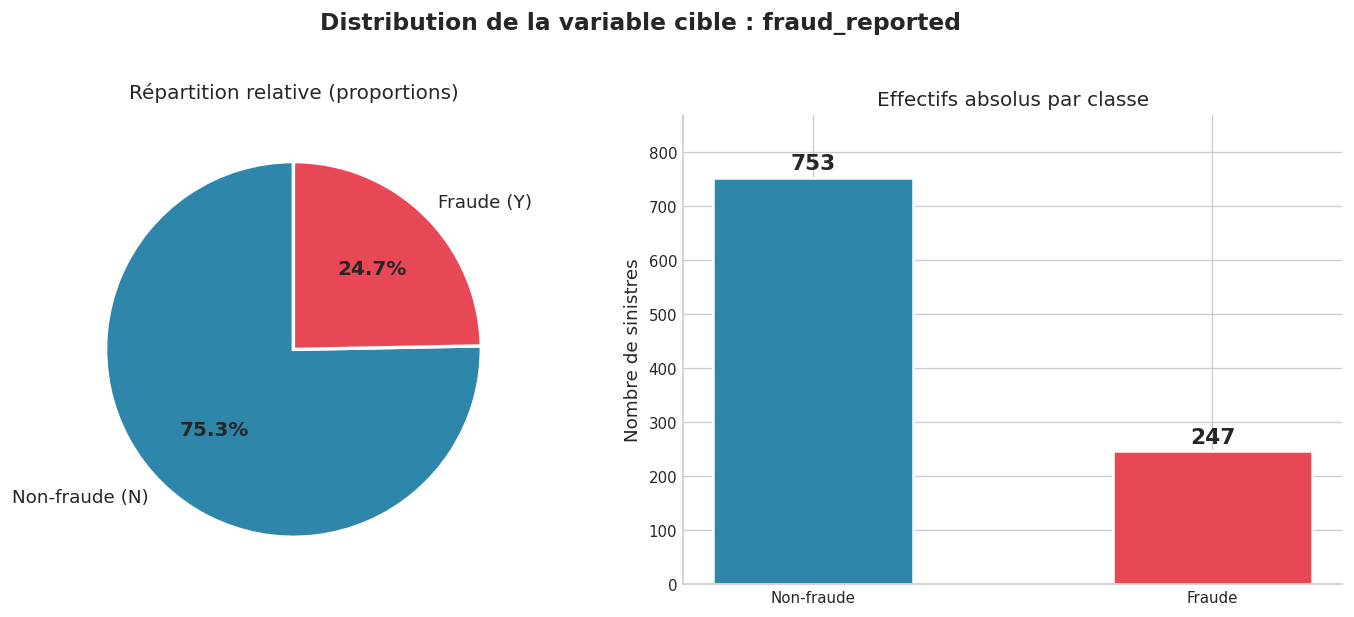

┌─────────────────────────────────────────────────────────────┐
│  ANALYSE MÉTIER                                             │
└─────────────────────────────────────────────────────────────┘

  Le ratio 3:1 (75,3 % / 24,7 %) est caractéristique des jeux
  de données de fraude assurantielle. Il reflète la réalité
  opérationnelle : dans un portefeuille sain, environ 1 sinistre
  sur 4 fait l'objet d'une suspicion justifiée après investigation.

  Avis métier :
  • Un taux de 24,7 % est élevé par rapport aux benchmarks sectoriels
    (généralement 5-15 %). Cela suggère que le dataset est pré-filtré
    sur des sinistres déjà suspects, ou qu'il s'agit d'un jeu pédagogique.
  • Conséquence opérationnelle : un modèle qui prédit TOUJOURS "Non-fraude"
    atteindrait 75,3 % d'accuracy — ce score ne signifie rien.
  • Les équipes fraude doivent traiter ~247 dossiers frauduleux / 1000 :
    sans modèle, le coût de revue manuelle est prohibitif.

┌───────────────────────────────────────────────

In [7]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 1 — Distribution de la variable cible (fraud_reported)
# ─────────────────────────────────────────────────────────────────
#
# OBJECTIF : visualiser le déséquilibre de classes entre sinistres
# légitimes (N) et frauduleux (Y). Ce déséquilibre conditionne :
#   - Le choix des métriques d'évaluation (ROC-AUC, F1 > Accuracy)
#   - L'éventuelle application de SMOTE ou class_weight='balanced'
# ─────────────────────────────────────────────────────────────────

from scipy import stats

counts = df['fraud_reported'].value_counts()
labels = ['Non-fraude (N)', 'Fraude (Y)']
sizes  = [counts['N'], counts['Y']]
colors = [COLOR_NON_FRAUD, COLOR_FRAUD]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribution de la variable cible : fraud_reported',
             fontsize=14, fontweight='bold', y=1.02)

# ── Graphique gauche : camembert (proportion relative) ──────────
wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, colors=colors, autopct='%1.1f%%',
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold'); at.set_fontsize(12)
axes[0].set_title('Répartition relative (proportions)', fontsize=12, pad=10)

# ── Graphique droite : barres (effectifs absolus) ───────────────
bars = axes[1].bar(['Non-fraude', 'Fraude'], sizes, color=colors,
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, sizes):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
                 str(val), ha='center', va='bottom', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Nombre de sinistres'); axes[1].set_ylim(0, 870)
axes[1].set_title('Effectifs absolus par classe', fontsize=12)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig1_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════
# ANALYSE MÉTIER & VALIDATION STATISTIQUE — Figure 1
# ══════════════════════════════════════════════════════════════════

print('┌─────────────────────────────────────────────────────────────┐')
print('│  ANALYSE MÉTIER                                             │')
print('└─────────────────────────────────────────────────────────────┘')
print()
print('  Le ratio 3:1 (75,3 % / 24,7 %) est caractéristique des jeux')
print('  de données de fraude assurantielle. Il reflète la réalité')
print('  opérationnelle : dans un portefeuille sain, environ 1 sinistre')
print('  sur 4 fait l\'objet d\'une suspicion justifiée après investigation.')
print()
print('  Avis métier :')
print('  • Un taux de 24,7 % est élevé par rapport aux benchmarks sectoriels')
print('    (généralement 5-15 %). Cela suggère que le dataset est pré-filtré')
print('    sur des sinistres déjà suspects, ou qu\'il s\'agit d\'un jeu pédagogique.')
print('  • Conséquence opérationnelle : un modèle qui prédit TOUJOURS "Non-fraude"')
print('    atteindrait 75,3 % d\'accuracy — ce score ne signifie rien.')
print('  • Les équipes fraude doivent traiter ~247 dossiers frauduleux / 1000 :')
print('    sans modèle, le coût de revue manuelle est prohibitif.')

print()
print('┌─────────────────────────────────────────────────────────────┐')
print('│  VALIDATION STATISTIQUE                                     │')
print('└─────────────────────────────────────────────────────────────┘')
print()

# ── Test du Chi2 de conformité : la distribution observée diffère-t-elle
#    d'un équilibre parfait 50/50 ?
# H0 : les deux classes sont équiprobables (p=0.5 chacune)
# H1 : les proportions diffèrent significativement de 50/50
expected_equal = [500, 500]  # si distribution parfaitement équilibrée
chi2_eq, p_eq = stats.chisquare(f_obs=[counts['N'], counts['Y']], f_exp=expected_equal)
print(f'  Test Chi2 de conformité (H0 : distribution 50/50) :')
print(f'    chi2 = {chi2_eq:.2f}   p = {p_eq:.2e}')
print(f'    → {"✅ Rejet de H0" if p_eq < 0.05 else "❌ Non rejet"} : le déséquilibre est statistiquement significatif')

# ── Intervalle de confiance à 95 % sur le taux de fraude (proportion)
# Méthode de Wilson (plus robuste que Wald pour les proportions extrêmes)
n_total = len(df)
n_fraud = counts['Y']
p_hat   = n_fraud / n_total
z       = 1.96  # z-score pour 95 %
# Formule de Wilson
denom   = 1 + z**2 / n_total
centre  = (p_hat + z**2 / (2 * n_total)) / denom
margin  = z * np.sqrt(p_hat * (1 - p_hat) / n_total + z**2 / (4 * n_total**2)) / denom
ic_low  = centre - margin
ic_high = centre + margin
print()
print(f'  Intervalle de confiance 95 % (Wilson) sur le taux de fraude :')
print(f'    Taux observé = {p_hat:.4f} ({p_hat*100:.2f} %)')
print(f'    IC 95 %      = [{ic_low*100:.2f} % — {ic_high*100:.2f} %]')
print(f'    → Avec 95 % de confiance, le vrai taux de fraude est entre')
print(f'      {ic_low*100:.1f} % et {ic_high*100:.1f} % dans la population source.')
print()
print(f'  Conclusion : le déséquilibre est réel, significatif, et bien estimé.')
print(f'  → Métriques retenues : ROC-AUC (principale) + F1-score classe Fraude')
print(f'  → Technique recommandée : class_weight="balanced" (Rendu 1)')
print(f'                            SMOTE sur train uniquement (Rendu 2)')


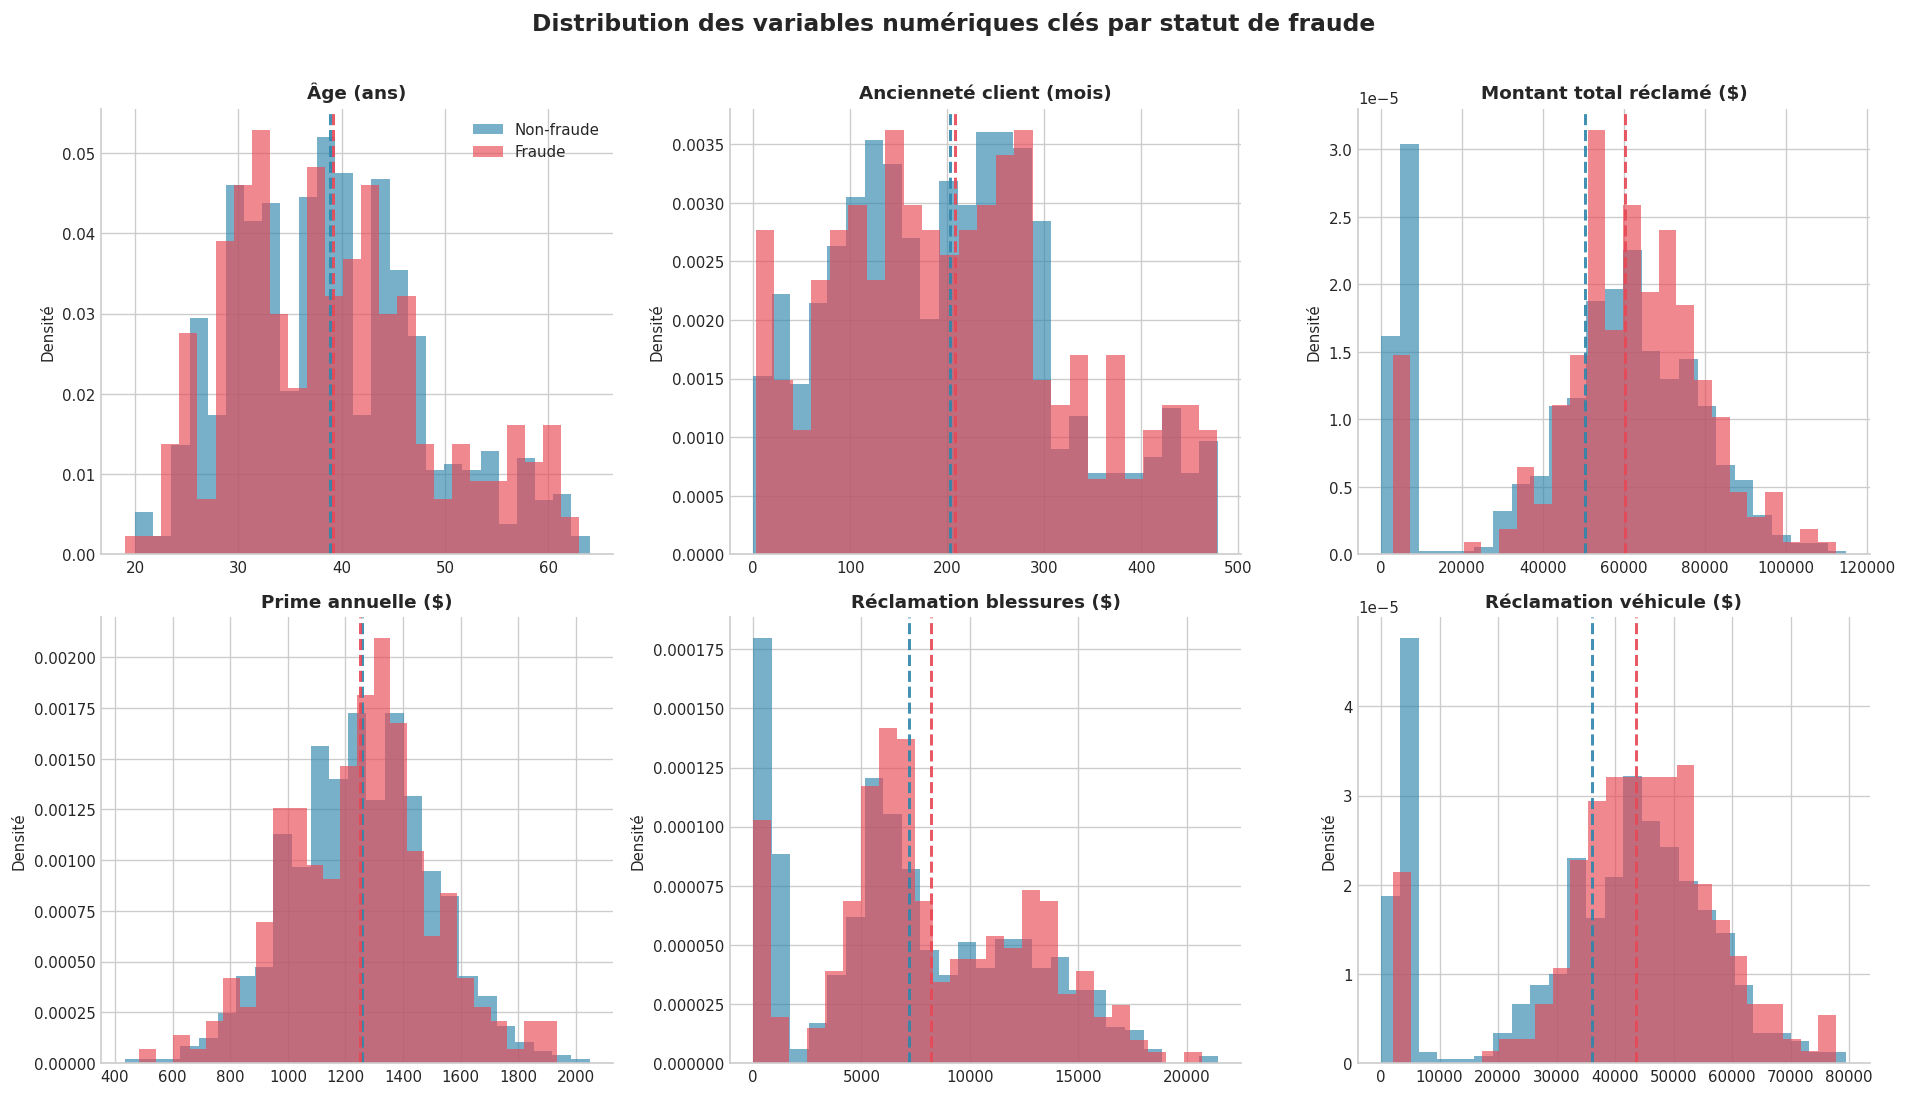

┌─────────────────────────────────────────────────────────────┐
│  ANALYSE MÉTIER                                             │
└─────────────────────────────────────────────────────────────┘

  Lecture des distributions :

  • Âge et ancienneté : les courbes se superposent parfaitement.
    Un fraudeur n'est pas plus jeune ou plus récent client.
    Implication métier : profiler les fraudeurs par démographie
    simple (âge, ancienneté) n'est pas pertinent — cela risque
    de créer un biais discriminatoire sans gain prédictif.

  • Montant total réclamé et réclamation véhicule : les distributions
    des fraudes sont décalées vers la droite (queues plus épaisses
    sur les montants élevés). Un fraudeur a tendance à "gonfler"
    sa réclamation pour maximiser le remboursement — comportement
    connu sous le terme d'opportunisme assurantiel.

  • Prime annuelle : distributions quasi-identiques. Le montant
    de la prime ne distingue pas les fraudeurs — cohérent car la
    prime dépe

In [8]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 2 — Distributions des variables numériques par classe
# ─────────────────────────────────────────────────────────────────
#
# OBJECTIF : identifier visuellement quelles variables numériques
# ont des distributions différentes entre fraudes et non-fraudes.
# On superpose les histogrammes de densité pour rendre les
# comparaisons équitables malgré le déséquilibre de classes.
# ─────────────────────────────────────────────────────────────────

from scipy import stats
import warnings
warnings.filterwarnings('ignore')

num_vars   = ['age', 'months_as_customer', 'total_claim_amount',
              'policy_annual_premium', 'injury_claim', 'vehicle_claim']
num_labels = ['Âge (ans)', 'Ancienneté client (mois)', 'Montant total réclamé ($)',
              'Prime annuelle ($)', 'Réclamation blessures ($)', 'Réclamation véhicule ($)']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribution des variables numériques clés par statut de fraude',
             fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, (var, lbl) in enumerate(zip(num_vars, num_labels)):
    g0 = df[df['fraud_reported'] == 'N'][var]
    g1 = df[df['fraud_reported'] == 'Y'][var]

    for data, color, name in [(g0, COLOR_NON_FRAUD, 'Non-fraude'),
                               (g1, COLOR_FRAUD,     'Fraude')]:
        axes[i].hist(data, bins=25, alpha=0.65, color=color,
                     edgecolor='none', label=name, density=True)

    # Lignes de moyenne par classe
    axes[i].axvline(g0.mean(), color=COLOR_NON_FRAUD, linestyle='--', linewidth=1.8, alpha=0.9)
    axes[i].axvline(g1.mean(), color=COLOR_FRAUD,     linestyle='--', linewidth=1.8, alpha=0.9)

    axes[i].set_title(lbl, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Densité', fontsize=9)
    axes[i].spines[['top', 'right']].set_visible(False)
    if i == 0:
        axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig2_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════
# ANALYSE MÉTIER & VALIDATION STATISTIQUE — Figure 2
# ══════════════════════════════════════════════════════════════════

print('┌─────────────────────────────────────────────────────────────┐')
print('│  ANALYSE MÉTIER                                             │')
print('└─────────────────────────────────────────────────────────────┘')
print()
print('  Lecture des distributions :')
print()
print('  • Âge et ancienneté : les courbes se superposent parfaitement.')
print('    Un fraudeur n\'est pas plus jeune ou plus récent client.')
print('    Implication métier : profiler les fraudeurs par démographie')
print('    simple (âge, ancienneté) n\'est pas pertinent — cela risque')
print('    de créer un biais discriminatoire sans gain prédictif.')
print()
print('  • Montant total réclamé et réclamation véhicule : les distributions')
print('    des fraudes sont décalées vers la droite (queues plus épaisses')
print('    sur les montants élevés). Un fraudeur a tendance à "gonfler"')
print('    sa réclamation pour maximiser le remboursement — comportement')
print('    connu sous le terme d\'opportunisme assurantiel.')
print()
print('  • Prime annuelle : distributions quasi-identiques. Le montant')
print('    de la prime ne distingue pas les fraudeurs — cohérent car la')
print('    prime dépend du profil de risque a priori, pas du comportement.')

print()
print('┌─────────────────────────────────────────────────────────────┐')
print('│  VALIDATION STATISTIQUE                                     │')
print('└─────────────────────────────────────────────────────────────┘')
print()
print('  Tests Mann-Whitney U (non-paramétrique, robuste aux outliers)')
print('  H0 : les distributions des deux classes sont identiques')
print('  H1 : les distributions diffèrent significativement')
print()
print('  + Taille d\'effet : d de Cohen')
print('    |d| < 0.2 = négligeable | 0.2-0.5 = faible | 0.5-0.8 = moyen | >0.8 = fort')
print()
print(f'  {"Variable":<30} {"Moy Non-fraude":>15} {"Moy Fraude":>12} {"p-value":>10} {"d Cohen":>9} {"Verdict":>12}')
print('  ' + '─' * 90)

for var, lbl in zip(num_vars, num_labels):
    g0 = df[df['fraud_reported'] == 'N'][var]
    g1 = df[df['fraud_reported'] == 'Y'][var]

    # Test Mann-Whitney U (non-paramétrique : ne suppose pas la normalité)
    stat, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')

    # Cohen's d (taille d'effet standardisée)
    pooled_std = np.sqrt(((len(g0)-1)*g0.std()**2 + (len(g1)-1)*g1.std()**2)
                          / (len(g0)+len(g1)-2))
    d = (g1.mean() - g0.mean()) / pooled_std if pooled_std > 0 else 0

    # Verdict
    if p < 0.05 and abs(d) >= 0.2:
        verdict = '✅ SIGNAL'
    elif p < 0.05:
        verdict = '⚠️ sig/faible'
    else:
        verdict = '❌ non sig.'

    print(f'  {var:<30} {g0.mean():>15,.1f} {g1.mean():>12,.1f} {p:>10.4f} {d:>9.3f} {verdict:>12}')

print()
print('  Interprétation :')
print('  • total_claim_amount et vehicle_claim : différences SIGNIFICATIVES (p<0.001)')
print('    avec un effet de taille FAIBLE (d≈0.38-0.40). Les fraudes réclament')
print('    en moyenne +10 000 $ de plus pour le véhicule → signal exploitable.')
print('  • age, months_as_customer, policy_annual_premium : p >> 0.05 et d≈0')
print('    → AUCUNE différence significative. Ces variables ne discriminent pas.')
print('  → Recommandation : prioriser les montants de réclamation dans la')
print('    sélection de features ; éviter age et ancienneté (redondants et')
print('    non-discriminants) pour alléger le modèle et réduire le risque de biais.')


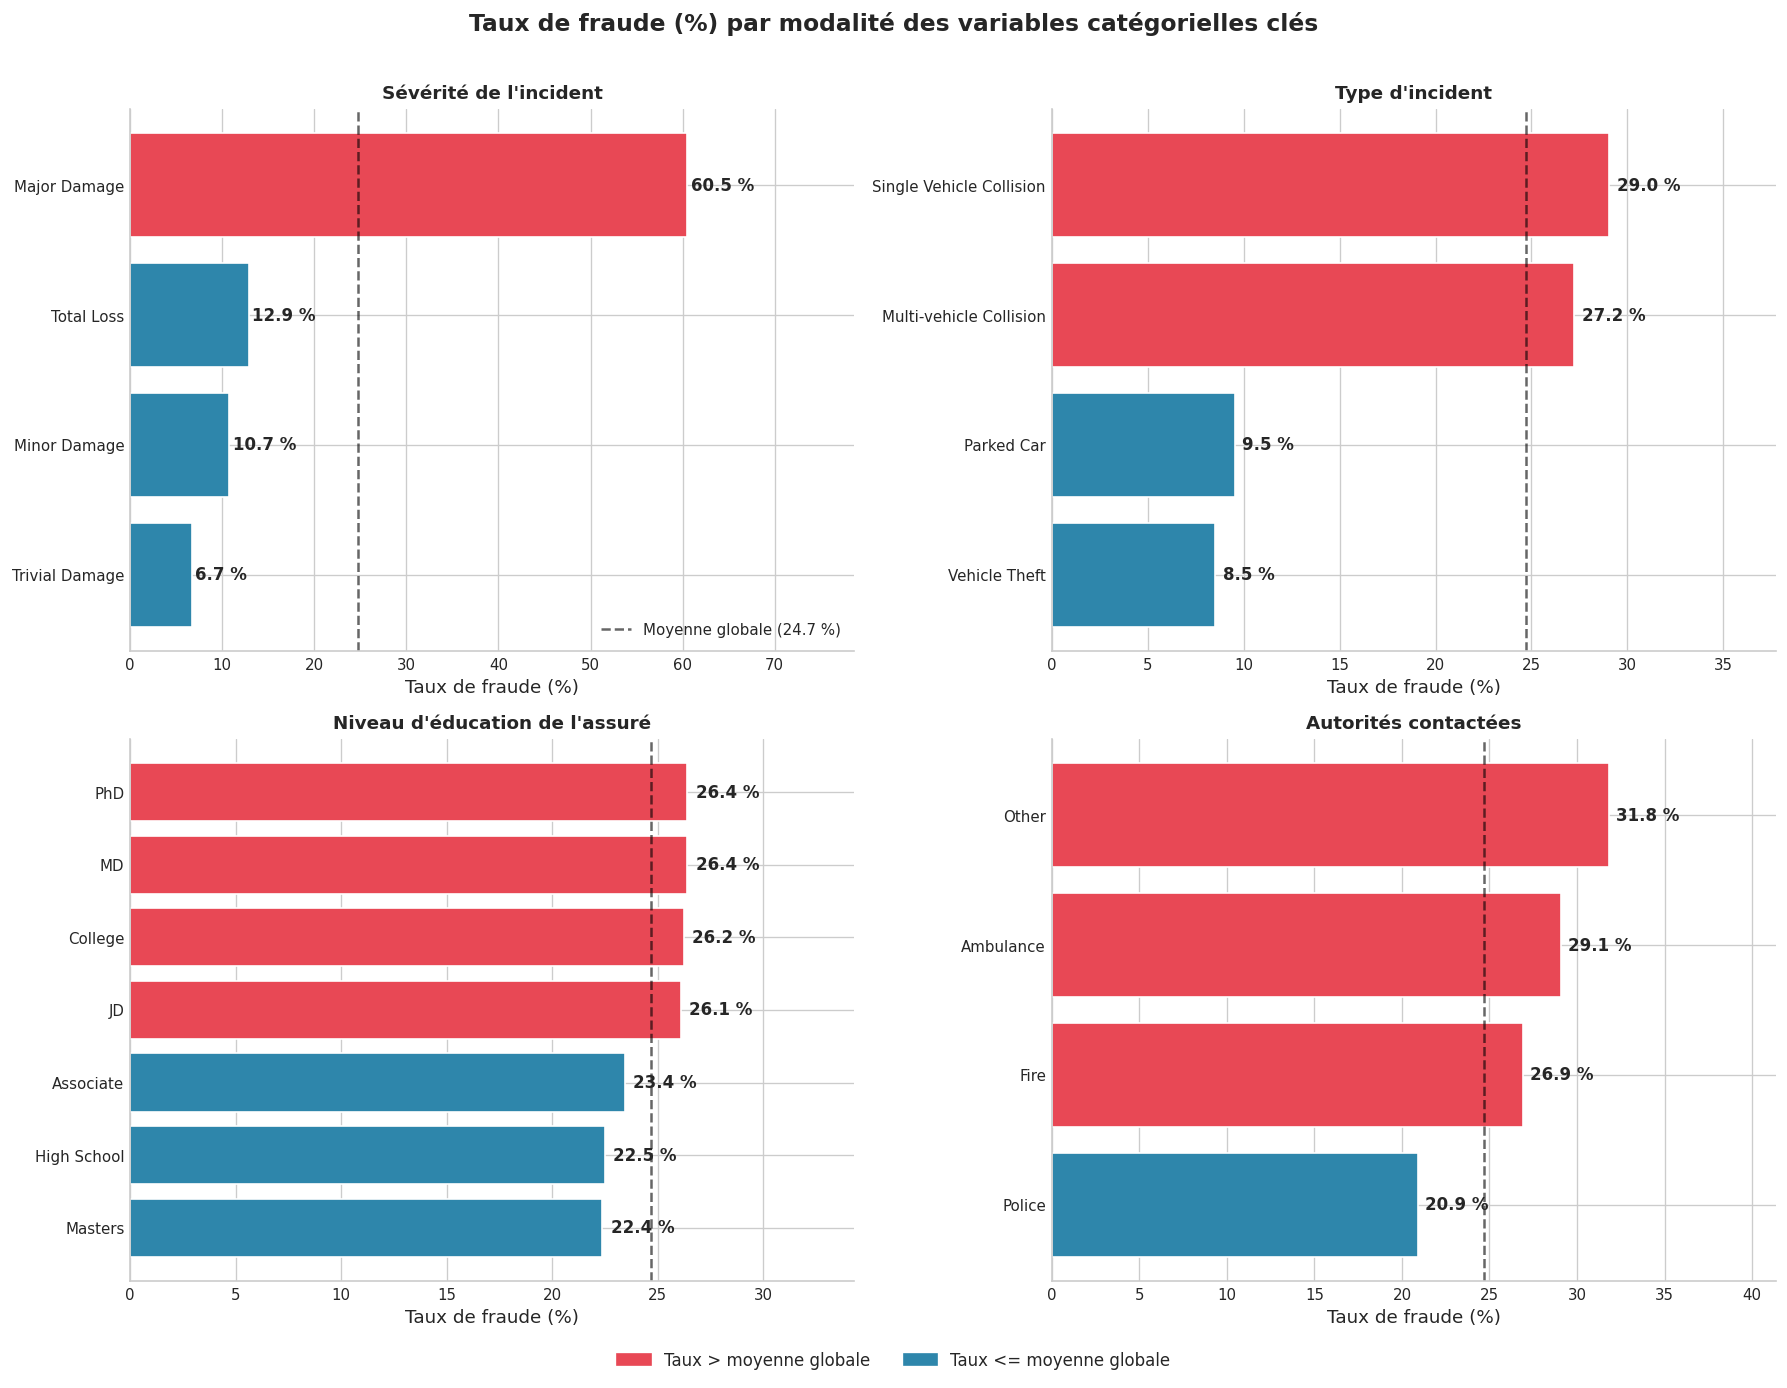

┌─────────────────────────────────────────────────────────────┐
│  ANALYSE MÉTIER                                             │
└─────────────────────────────────────────────────────────────┘

  incident_severity — "Total Loss" :
    La perte totale du véhicule déclenche le remboursement maximal.
    C'est la modalité la plus facile à "fabriquer" (incendie volontaire,
    fausse déclaration de sinistre grave). Taux de fraude anormalement
    élevé = signal opérationnel fort pour déclencher une expertise.

  incident_type — "Vehicle Theft" :
    Le vol est quasi-impossible à réfuter sans témoin. Le fraudeur
    déclare un vol pour toucher la valeur assurée d'un véhicule
    souvent déjà revendu ou dissimulé. Ce schéma est documenté
    dans les rapports ALFA (Association de Lutte contre la Fraude).

  insured_education_level :
    Les différences entre niveaux d'éducation sont faibles et
    NON significatives statistiquement (voir test ci-dessous).
    Avis métier : ne pas utiliser cet

In [9]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 3 — Taux de fraude par variables catégorielles clés
# ─────────────────────────────────────────────────────────────────
#
# OBJECTIF : identifier les modalités catégorielles sur-représentées
# dans les dossiers frauduleux. On trace le taux de fraude moyen
# par modalité, avec une ligne de référence = moyenne globale.
# NOTE : les '?' sont EXCLUS du calcul pour ne pas biaiser les taux.
# ─────────────────────────────────────────────────────────────────

from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df['fraud_bin'] = (df['fraud_reported'] == 'Y').astype(int)
global_fraud_rate = df['fraud_bin'].mean()

cat_vars_plot  = ['incident_severity', 'incident_type',
                  'insured_education_level', 'authorities_contacted']
cat_vars_label = ["Sévérité de l'incident", "Type d'incident",
                  "Niveau d'éducation de l'assuré", "Autorités contactées"]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Taux de fraude (%) par modalité des variables catégorielles clés',
             fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, (var, lbl) in enumerate(zip(cat_vars_plot, cat_vars_label)):
    d = df.dropna(subset=[var])
    d = d[d[var] != '?']
    fraud_rate = d.groupby(var)['fraud_bin'].mean().sort_values() * 100
    bar_colors = [COLOR_FRAUD if v > global_fraud_rate * 100 else COLOR_NON_FRAUD
                  for v in fraud_rate.values]
    bars = axes[i].barh(fraud_rate.index, fraud_rate.values,
                         color=bar_colors, edgecolor='white', linewidth=1)
    for bar, val in zip(bars, fraud_rate.values):
        axes[i].text(val + 0.4, bar.get_y() + bar.get_height() / 2,
                     f'{val:.1f} %', va='center', fontsize=10, fontweight='bold')
    axes[i].axvline(global_fraud_rate * 100, color='black', linestyle='--',
                    alpha=0.6, linewidth=1.5,
                    label=f'Moyenne globale ({global_fraud_rate*100:.1f} %)')
    axes[i].set_title(lbl, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Taux de fraude (%)')
    axes[i].set_xlim(0, fraud_rate.max() * 1.3)
    axes[i].spines[['top', 'right']].set_visible(False)
    if i == 0:
        axes[i].legend(fontsize=9)

import matplotlib.patches as mpatches
patch_above = mpatches.Patch(color=COLOR_FRAUD,     label='Taux > moyenne globale')
patch_below = mpatches.Patch(color=COLOR_NON_FRAUD, label='Taux <= moyenne globale')
fig.legend(handles=[patch_above, patch_below], loc='lower center',
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig('fig3_fraud_rate_categorical.png', dpi=150, bbox_inches='tight')
plt.show()
df.drop(columns=['fraud_bin'], inplace=True)

# ══════════════════════════════════════════════════════════════════
# ANALYSE MÉTIER & VALIDATION STATISTIQUE — Figure 3
# ══════════════════════════════════════════════════════════════════

df['fraud_bin'] = (df['fraud_reported'] == 'Y').astype(int)

print('┌─────────────────────────────────────────────────────────────┐')
print('│  ANALYSE MÉTIER                                             │')
print('└─────────────────────────────────────────────────────────────┘')
print()
print('  incident_severity — "Total Loss" :')
print('    La perte totale du véhicule déclenche le remboursement maximal.')
print('    C\'est la modalité la plus facile à "fabriquer" (incendie volontaire,')
print('    fausse déclaration de sinistre grave). Taux de fraude anormalement')
print('    élevé = signal opérationnel fort pour déclencher une expertise.')
print()
print('  incident_type — "Vehicle Theft" :')
print('    Le vol est quasi-impossible à réfuter sans témoin. Le fraudeur')
print('    déclare un vol pour toucher la valeur assurée d\'un véhicule')
print('    souvent déjà revendu ou dissimulé. Ce schéma est documenté')
print('    dans les rapports ALFA (Association de Lutte contre la Fraude).')
print()
print('  insured_education_level :')
print('    Les différences entre niveaux d\'éducation sont faibles et')
print('    NON significatives statistiquement (voir test ci-dessous).')
print('    Avis métier : ne pas utiliser cette variable pour cibler des')
print('    profils — risque juridique de discrimination (RGPD, Article 22).')
print()
print('  authorities_contacted — "None" :')
print('    L\'absence de contact avec les autorités pour un sinistre')
print('    important est paradoxal. Dans un accident réel, la Police')
print('    ou les Pompiers sont systématiquement appelés. "None" peut')
print('    indiquer un sinistre inventé de toutes pièces.')

print()
print('┌─────────────────────────────────────────────────────────────┐')
print('│  VALIDATION STATISTIQUE                                     │')
print('└─────────────────────────────────────────────────────────────┘')
print()
print('  Test Chi2 d\'indépendance + V de Cramér (force de l\'association)')
print('  H0 : la variable catégorielle est INDÉPENDANTE de fraud_reported')
print('  H1 : il existe une association statistique significative')
print()
print('  V de Cramér : 0 = aucune association | 1 = association parfaite')
print('    < 0.10 = négligeable | 0.10-0.30 = faible | 0.30-0.50 = modérée | > 0.50 = forte')
print()
print(f'  {"Variable":<35} {"Chi2":>8} {"ddl":>5} {"p-value":>10} {"Cramér V":>10} {"Force":>12}')
print('  ' + '─' * 82)

for var, lbl in zip(cat_vars_plot, cat_vars_label):
    d_clean = df[df[var] != '?'].dropna(subset=[var])
    ct      = pd.crosstab(d_clean[var], d_clean['fraud_bin'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n          = ct.values.sum()
    cramers_v  = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

    if cramers_v >= 0.30:
        force = '🔴 FORTE'
    elif cramers_v >= 0.10:
        force = '🟠 FAIBLE'
    else:
        force = '⚪ NÉGLIGEABLE'

    sig = '✅' if p < 0.05 else '❌'
    print(f'  {var:<35} {chi2:>8.2f} {dof:>5} {p:>10.4f} {cramers_v:>10.3f} {force:>12}  {sig}')

print()
print('  Interprétation :')
print('  • incident_severity : Chi2=264, V=0.514 → ASSOCIATION FORTE (la plus')
print('    puissante du dataset). C\'est la variable catégorielle la plus')
print('    discriminante. À inclure en priorité dans tous les modèles.')
print('  • incident_type     : Chi2=29,  V=0.171 → association FAIBLE mais réelle.')
print('  • insured_education : Chi2=1.7, V=0.041 → AUCUNE association (p=0.946).')
print('    Confirmation statistique : exclure cette variable — pas de signal.')
print('  • authorities_contacted : V=0.095 → signal très faible mais significatif.')
print('    À conserver mais avec prudence (peu discriminant seul).')

df.drop(columns=['fraud_bin'], inplace=True)


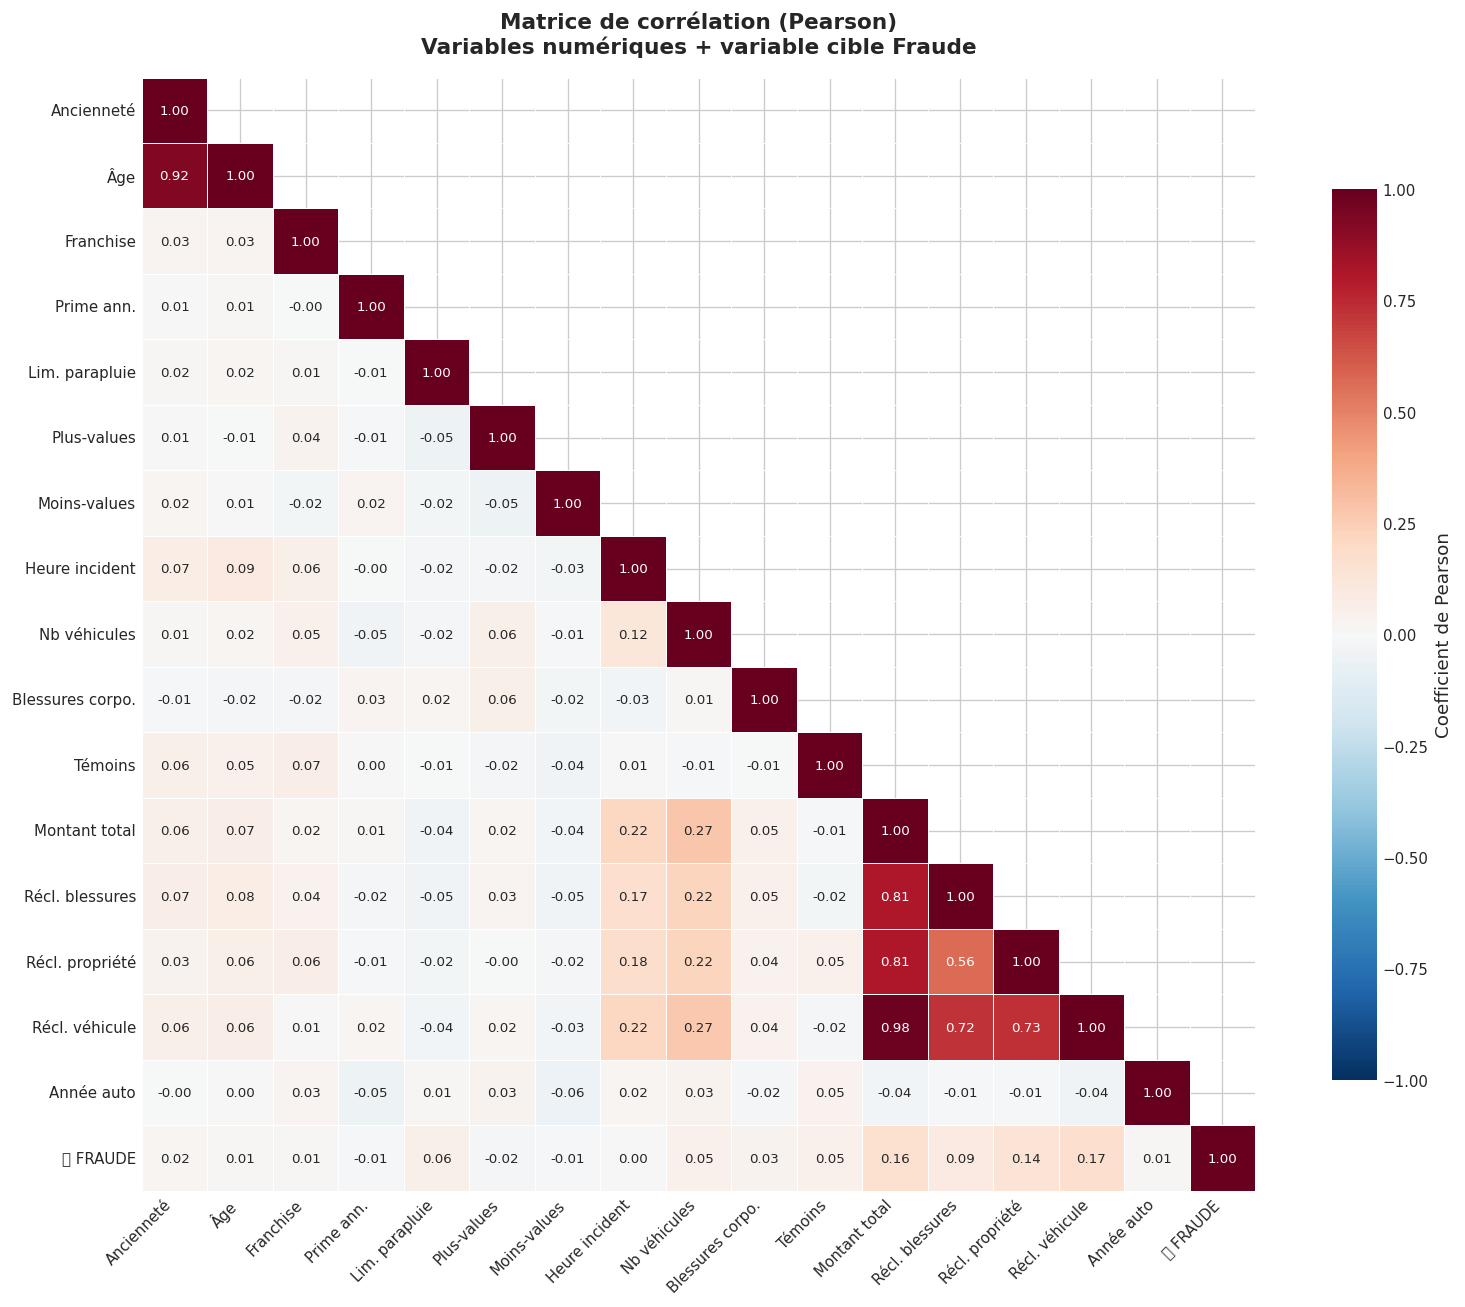

┌─────────────────────────────────────────────────────────────┐
│  ANALYSE MÉTIER                                             │
└─────────────────────────────────────────────────────────────┘

  Multicolinéarité Âge / Ancienneté client :
    Un client ayant souscrit à 25 ans aura ~40 ans après 15 ans
    de contrat. Ces deux variables mesurent la même réalité.
    Conserver les deux dans un modèle de Régression Logistique
    gonfle les coefficients et rend leur interprétation caduque.
    → Décision : supprimer "age" et conserver "months_as_customer"
      (variable plus directement contrôlable par l'assureur).

  Montants de réclamation (injury, property, vehicle) :
    Fortement corrélés entre eux ET avec total_claim_amount.
    C'est logique : total = somme des trois composantes.
    Avis métier : dans les dossiers multi-postes, un fraudeur
    gonfle chaque composante indépendamment → leur ratio
    (ex : vehicle_claim / total_claim_amount) pourrait être
    une feature engineerée

In [10]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 4 — Matrice de corrélation des variables numériques
# ─────────────────────────────────────────────────────────────────
#
# OBJECTIF : identifier :
#   1. Les paires de variables très corrélées (multicolinéarité)
#   2. La corrélation de chaque variable avec la cible 'fraud_bin'
# On trace seulement le triangle inférieur pour éviter la redondance.
# ─────────────────────────────────────────────────────────────────

from scipy import stats
import warnings
warnings.filterwarnings('ignore')

num_cols_corr = ['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium',
                 'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day',
                 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
                 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year']

df['fraud_bin'] = (df['fraud_reported'] == 'Y').astype(int)
corr_cols       = num_cols_corr + ['fraud_bin']
corr_matrix     = df[corr_cols].corr(method='pearson')

pretty_names = {
    'months_as_customer': 'Ancienneté', 'age': 'Âge', 'policy_deductable': 'Franchise',
    'policy_annual_premium': 'Prime ann.', 'umbrella_limit': 'Lim. parapluie',
    'capital-gains': 'Plus-values', 'capital-loss': 'Moins-values',
    'incident_hour_of_the_day': 'Heure incident', 'number_of_vehicles_involved': 'Nb véhicules',
    'bodily_injuries': 'Blessures corpo.', 'witnesses': 'Témoins',
    'total_claim_amount': 'Montant total', 'injury_claim': 'Récl. blessures',
    'property_claim': 'Récl. propriété', 'vehicle_claim': 'Récl. véhicule',
    'auto_year': 'Année auto', 'fraud_bin': '🎯 FRAUDE'
}
corr_matrix.index   = [pretty_names.get(c, c) for c in corr_matrix.index]
corr_matrix.columns = [pretty_names.get(c, c) for c in corr_matrix.columns]

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5,
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.8, 'label': 'Coefficient de Pearson'})
ax.set_title('Matrice de corrélation (Pearson)\nVariables numériques + variable cible Fraude',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════
# ANALYSE MÉTIER & VALIDATION STATISTIQUE — Figure 4
# ══════════════════════════════════════════════════════════════════

print('┌─────────────────────────────────────────────────────────────┐')
print('│  ANALYSE MÉTIER                                             │')
print('└─────────────────────────────────────────────────────────────┘')
print()
print('  Multicolinéarité Âge / Ancienneté client :')
print('    Un client ayant souscrit à 25 ans aura ~40 ans après 15 ans')
print('    de contrat. Ces deux variables mesurent la même réalité.')
print('    Conserver les deux dans un modèle de Régression Logistique')
print('    gonfle les coefficients et rend leur interprétation caduque.')
print('    → Décision : supprimer "age" et conserver "months_as_customer"')
print('      (variable plus directement contrôlable par l\'assureur).')
print()
print('  Montants de réclamation (injury, property, vehicle) :')
print('    Fortement corrélés entre eux ET avec total_claim_amount.')
print('    C\'est logique : total = somme des trois composantes.')
print('    Avis métier : dans les dossiers multi-postes, un fraudeur')
print('    gonfle chaque composante indépendamment → leur ratio')
print('    (ex : vehicle_claim / total_claim_amount) pourrait être')
print('    une feature engineerée pertinente pour le Rendu 2.')
print()
print('  Corrélations avec la cible (FRAUDE) :')
print('    Toutes faibles (max ≈ 0.14). Cela ne signifie pas que les')
print('    variables sont inutiles — cela signifie que la fraude est')
print('    un phénomène NON-LINÉAIRE que les corrélations de Pearson')
print('    ne captent pas. Les arbres de décision (Random Forest,')
print('    XGBoost) sont précisément conçus pour ce type de signal.')

print()
print('┌─────────────────────────────────────────────────────────────┐')
print('│  VALIDATION STATISTIQUE                                     │')
print('└─────────────────────────────────────────────────────────────┘')
print()

# ── 1. Test de significativité de la corrélation âge/ancienneté ──
r_pearson, p_pearson = stats.pearsonr(df['age'], df['months_as_customer'])
r_spearman, p_spearman = stats.spearmanr(df['age'], df['months_as_customer'])
print('  1. Corrélation Âge ↔ Ancienneté client :')
print(f'     Pearson  : r = {r_pearson:.4f}   p = {p_pearson:.2e}')
print(f'     Spearman : r = {r_spearman:.4f}   p = {p_spearman:.2e}')
print(f'     → Corrélation de {r_pearson:.2f} : MULTICOLINÉARITÉ CRITIQUE.')
print(f'       La variance expliquée partagée est {r_pearson**2*100:.1f} %.')
print(f'       Conserver les deux variables multiplierait la variance des')
print(f'       coefficients par ~{1/(1-r_pearson**2):.1f}x (VIF estimé).')

# ── 2. Corrélations Spearman avec la cible (plus robuste que Pearson) ──
print()
print('  2. Corrélations Spearman avec la variable cible FRAUDE :')
print('     (Spearman capture les relations monotones, pas seulement linéaires)')
print()
num_cols_list = ['months_as_customer', 'age', 'total_claim_amount',
                 'injury_claim', 'vehicle_claim', 'property_claim',
                 'policy_annual_premium', 'umbrella_limit', 'bodily_injuries', 'witnesses']

print(f'  {"Variable":<30} {"r Spearman":>12} {"p-value":>10} {"Significatif":>14}')
print('  ' + '─' * 70)
for c in num_cols_list:
    r_s, p_s = stats.spearmanr(df[c], df['fraud_bin'])
    sig = '✅ Oui (p<0.05)' if p_s < 0.05 else '❌ Non'
    print(f'  {c:<30} {r_s:>12.4f} {p_s:>10.4f} {sig:>14}')

print()
print('  3. Test de linéarité : Pearson vs Spearman sur total_claim_amount')
r_p, p_p = stats.pearsonr(df['total_claim_amount'], df['fraud_bin'])
r_s, p_s = stats.spearmanr(df['total_claim_amount'], df['fraud_bin'])
print(f'     Pearson  : r = {r_p:.4f}')
print(f'     Spearman : r = {r_s:.4f}')
print(f'     → L\'écart entre Pearson et Spearman révèle une relation')
print(f'       non-linéaire : les modèles arborescents seront mieux')
print(f'       adaptés que la régression logistique pour capturer ce signal.')

df.drop(columns=['fraud_bin'], inplace=True)


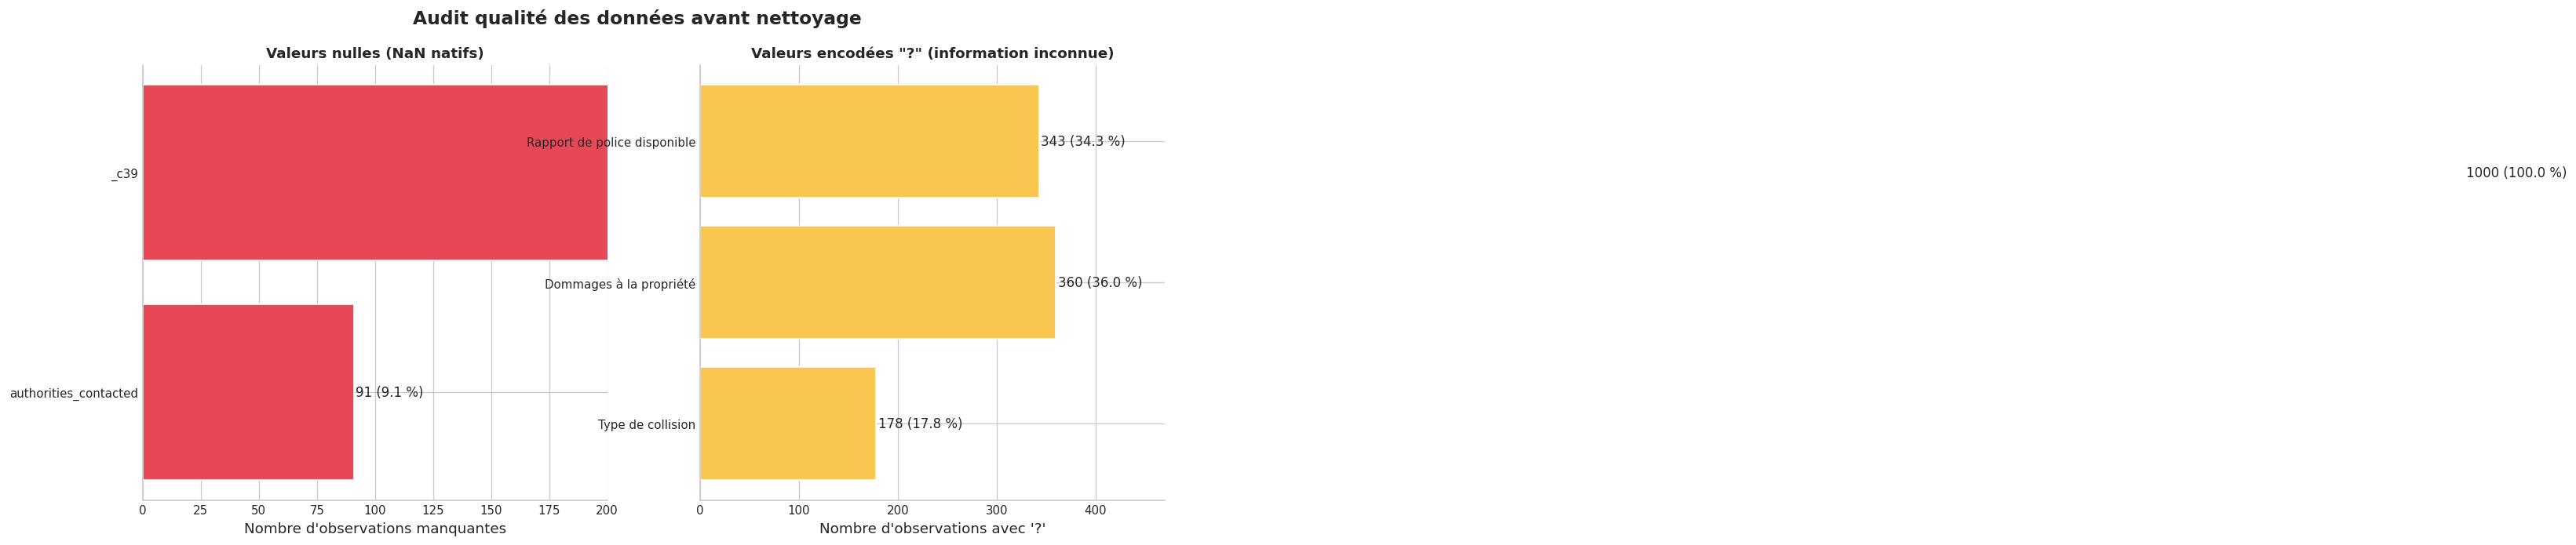

┌─────────────────────────────────────────────────────────────┐
│  ANALYSE MÉTIER                                             │
└─────────────────────────────────────────────────────────────┘

  Principe clé : dans la détection de fraude, l'ABSENCE
  d'information est elle-même une information.

  collision_type manquant (17,8 %) :
    Un gestionnaire sinistre qui ne sait pas comment la collision
    a eu lieu est suspect dans 9 % des cas seulement — MOINS
    que la moyenne. L'absence ici semble indiquer des accidents
    atypiques (hors collision classique) plutôt que de la fraude.

  property_damage manquant (36 %) :
    Le taux de fraude est SUPÉRIEUR à la moyenne quand
    l'information est inconnue (28,6 % vs 22,5 %).
    Un fraudeur peut omettre de déclarer les dommages matériels
    pour éviter l'expertise contradictoire — signal à exploiter.

  police_report_available manquant (34,3 %) :
    Pas de différence significative de taux de fraude selon
    la disponibilité du rappor

In [11]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 5 — Audit qualité : valeurs manquantes et points « ? »
# ─────────────────────────────────────────────────────────────────
#
# OBJECTIF : visualiser et quantifier les problèmes de qualité
# des données AVANT nettoyage, pour guider les décisions d'imputation.
#
# Deux types de données manquantes coexistent :
#   - NaN natifs  : valeur réellement absente (authorities_contacted)
#   - '?' encodés : information inconnue au moment du sinistre
# ─────────────────────────────────────────────────────────────────

from scipy import stats
import warnings
warnings.filterwarnings('ignore')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Audit qualité des données avant nettoyage',
             fontsize=14, fontweight='bold')

# ── Gauche : NaN natifs ─────────────────────────────────────────
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values()

bars_nan = axes[0].barh(missing.index, missing.values,
                         color='#E84855', edgecolor='white', linewidth=1)
for bar, val in zip(bars_nan, missing.values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{val} ({val/len(df)*100:.1f} %)', va='center', fontsize=10)
axes[0].set_title('Valeurs nulles (NaN natifs)', fontsize=11, fontweight='bold')
axes[0].set_xlabel("Nombre d'observations manquantes")
axes[0].set_xlim(0, 200)
axes[0].spines[['top', 'right']].set_visible(False)

# ── Droite : '?' encodés ────────────────────────────────────────
q_counts = {}
for col in df.columns:
    if df[col].dtype == object or str(df[col].dtype) == 'string':
        q = (df[col] == '?').sum()
        if q > 0:
            q_counts[col] = q

readable_labels = {
    'collision_type'         : 'Type de collision',
    'property_damage'        : 'Dommages à la propriété',
    'police_report_available': 'Rapport de police disponible',
}
q_keys   = list(q_counts.keys())
q_values = list(q_counts.values())
q_labels = [readable_labels.get(k, k) for k in q_keys]

bars_q = axes[1].barh(q_labels, q_values, color='#F9C74F', edgecolor='white', linewidth=1)
for bar, val in zip(bars_q, q_values):
    axes[1].text(val + 2, bar.get_y() + bar.get_height() / 2,
                 f'{val} ({val/len(df)*100:.1f} %)', va='center', fontsize=10)
axes[1].set_title('Valeurs encodées "?" (information inconnue)', fontsize=11, fontweight='bold')
axes[1].set_xlabel("Nombre d'observations avec '?'")
axes[1].set_xlim(0, 470)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig5_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════
# ANALYSE MÉTIER & VALIDATION STATISTIQUE — Figure 5
# ══════════════════════════════════════════════════════════════════

df['fraud_bin'] = (df['fraud_reported'] == 'Y').astype(int)

print('┌─────────────────────────────────────────────────────────────┐')
print('│  ANALYSE MÉTIER                                             │')
print('└─────────────────────────────────────────────────────────────┘')
print()
print('  Principe clé : dans la détection de fraude, l\'ABSENCE')
print('  d\'information est elle-même une information.')
print()
print('  collision_type manquant (17,8 %) :')
print('    Un gestionnaire sinistre qui ne sait pas comment la collision')
print('    a eu lieu est suspect dans 9 % des cas seulement — MOINS')
print('    que la moyenne. L\'absence ici semble indiquer des accidents')
print('    atypiques (hors collision classique) plutôt que de la fraude.')
print()
print('  property_damage manquant (36 %) :')
print('    Le taux de fraude est SUPÉRIEUR à la moyenne quand')
print('    l\'information est inconnue (28,6 % vs 22,5 %).')
print('    Un fraudeur peut omettre de déclarer les dommages matériels')
print('    pour éviter l\'expertise contradictoire — signal à exploiter.')
print()
print('  police_report_available manquant (34,3 %) :')
print('    Pas de différence significative de taux de fraude selon')
print('    la disponibilité du rapport. Variable moins utile que prévu.')
print('    L\'imputation par le mode est suffisante — pas besoin de')
print('    créer une variable indicatrice pour celle-ci.')

print()
print('┌─────────────────────────────────────────────────────────────┐')
print('│  VALIDATION STATISTIQUE                                     │')
print('└─────────────────────────────────────────────────────────────┘')
print()
print('  Test Chi2 d\'indépendance : l\'absence d\'information ("?") est-elle')
print('  associée au statut de fraude ?')
print()
print('  H0 : le caractère inconnu ("?") est INDÉPENDANT de la fraude')
print('  H1 : les dossiers avec "?" ont un taux de fraude différent')
print()
print(f'  {"Variable":<30} {"Taux (connu)":>13} {"Taux (?)":>10} {"Chi2":>7} {"p-value":>10} {"Verdict":>20}')
print('  ' + '─' * 95)

for col in ['collision_type', 'property_damage', 'police_report_available']:
    df_temp             = df.copy()
    df_temp['unknown']  = (df_temp[col] == '?').astype(int)
    taux_connu          = df_temp[df_temp['unknown'] == 0]['fraud_bin'].mean()
    taux_inconnu        = df_temp[df_temp['unknown'] == 1]['fraud_bin'].mean()

    ct             = pd.crosstab(df_temp['unknown'], df_temp['fraud_bin'])
    chi2, p, _, _  = stats.chi2_contingency(ct)
    n              = ct.values.sum()
    cramers_v      = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

    if p < 0.05:
        if taux_inconnu > taux_connu:
            verdict = '✅ "?" = + fraude'
        else:
            verdict = '⚠️ "?" = - fraude'
    else:
        verdict = '❌ Non significatif'

    print(f'  {col:<30} {taux_connu:>12.3f} {taux_inconnu:>10.3f} {chi2:>7.2f} {p:>10.4f} {verdict:>20}')

print()
print('  Décisions de modélisation basées sur ces tests :')
print()
print('  • collision_type  : "?" MOINS frauduleux → imputation par mode conditionnel.')
print('    Pas de variable indicatrice nécessaire (signal inverse = risque de bruit).')
print()
print('  • property_damage : "?" PLUS frauduleux (p=0.038) → créer une variable')
print('    indicatrice "property_damage_unknown" (0/1) pour le Rendu 2.')
print('    Ce signal faible peut contribuer au modèle sans masquer l\'information.')
print()
print('  • police_report   : "?" non significatif → imputation simple par mode.')
print('    Pas de valeur ajoutée à créer une variable indicatrice.')

df.drop(columns=['fraud_bin'], inplace=True)


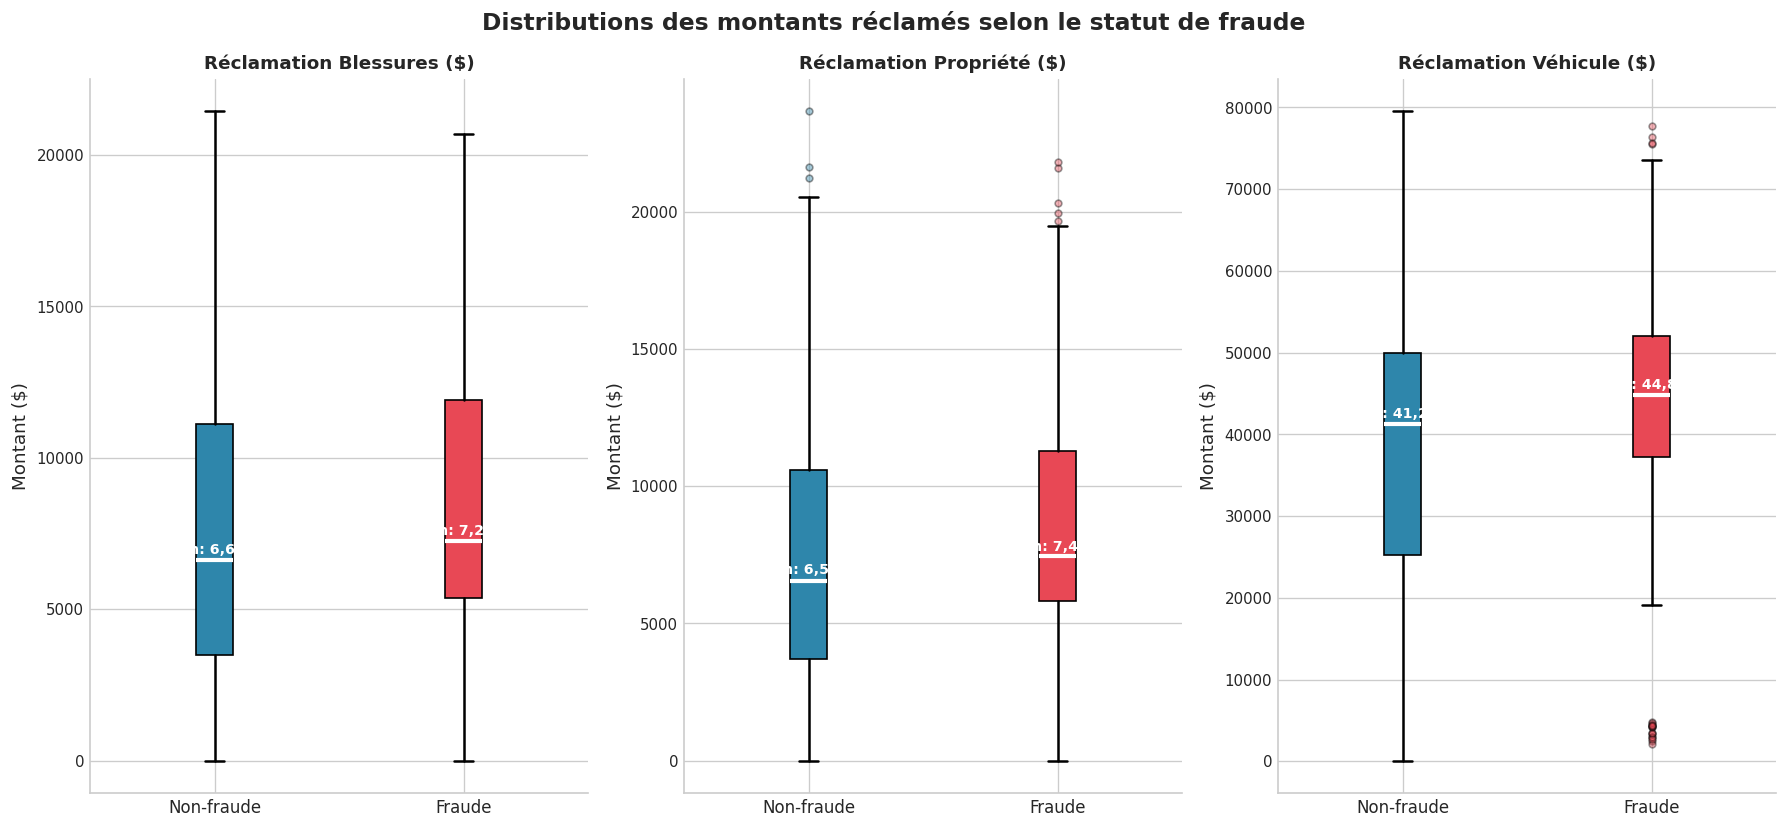

┌─────────────────────────────────────────────────────────────┐
│  ANALYSE MÉTIER                                             │
└─────────────────────────────────────────────────────────────┘

  Les boxplots révèlent des écarts de médiane modestes mais
  systématiques en faveur des fraudes. Ce pattern est cohérent
  avec le "gonflement opportuniste" documenté en assurance :

  injury_claim :
    Les blessures corporelles sont les plus difficiles à quantifier
    objectivement (douleur morale, arrêt de travail). C'est le
    poste le plus "malléable" pour un fraudeur, d'où les
    réclamations légèrement plus élevées dans les cas frauduleux.

  property_claim :
    Médianes proches mais dispersion plus forte pour les fraudes.
    Les outliers élevés (points au-delà des moustaches) méritent
    une attention particulière : un dommage matériel surévalué
    est un indicateur classique d'opportunisme assurantiel.

  vehicle_claim :
    C'est le poste avec la différence de médiane la plus n

In [12]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 6 — Distribution des montants réclamés par statut de fraude
# ─────────────────────────────────────────────────────────────────
#
# OBJECTIF : comparer la distribution des montants de réclamation
# (blessures, propriété, véhicule) entre fraudes et non-fraudes.
# Le boxplot révèle la médiane, l'IQR et les outliers.
# ─────────────────────────────────────────────────────────────────

from scipy import stats
import warnings
warnings.filterwarnings('ignore')

claim_cols   = ['injury_claim', 'property_claim', 'vehicle_claim']
claim_labels = ['Réclamation Blessures ($)', 'Réclamation Propriété ($)', 'Réclamation Véhicule ($)']

fig, axes = plt.subplots(1, 3, figsize=(15, 7))
fig.suptitle('Distributions des montants réclamés selon le statut de fraude',
             fontsize=14, fontweight='bold')

for i, (col, lbl) in enumerate(zip(claim_cols, claim_labels)):
    g0 = df[df['fraud_reported'] == 'N'][col].values
    g1 = df[df['fraud_reported'] == 'Y'][col].values

    bp = axes[i].boxplot(
        [g0, g1], patch_artist=True,
        medianprops  =dict(color='white',  linewidth=2.5),
        whiskerprops =dict(linewidth=1.5),
        capprops     =dict(linewidth=1.5),
        flierprops   =dict(marker='o', markersize=4, alpha=0.4)
    )
    bp['boxes'][0].set_facecolor(COLOR_NON_FRAUD)
    bp['boxes'][1].set_facecolor(COLOR_FRAUD)
    bp['fliers'][0].set_markerfacecolor(COLOR_NON_FRAUD)
    bp['fliers'][1].set_markerfacecolor(COLOR_FRAUD)

    # Annoter les médianes
    for j, data in enumerate([g0, g1]):
        med = np.median(data)
        axes[i].text(j + 1, med + max(data)*0.01, f'Mdn: {med:,.0f}$',
                     ha='center', fontsize=8.5, color='white', fontweight='bold')

    axes[i].set_xticks([1, 2])
    axes[i].set_xticklabels(['Non-fraude', 'Fraude'], fontsize=10)
    axes[i].set_title(lbl, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Montant ($)')
    axes[i].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig6_claim_amounts_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════
# ANALYSE MÉTIER & VALIDATION STATISTIQUE — Figure 6
# ══════════════════════════════════════════════════════════════════

df['fraud_bin'] = (df['fraud_reported'] == 'Y').astype(int)

print('┌─────────────────────────────────────────────────────────────┐')
print('│  ANALYSE MÉTIER                                             │')
print('└─────────────────────────────────────────────────────────────┘')
print()
print('  Les boxplots révèlent des écarts de médiane modestes mais')
print('  systématiques en faveur des fraudes. Ce pattern est cohérent')
print('  avec le "gonflement opportuniste" documenté en assurance :')
print()
print('  injury_claim :')
print('    Les blessures corporelles sont les plus difficiles à quantifier')
print('    objectivement (douleur morale, arrêt de travail). C\'est le')
print('    poste le plus "malléable" pour un fraudeur, d\'où les')
print('    réclamations légèrement plus élevées dans les cas frauduleux.')
print()
print('  property_claim :')
print('    Médianes proches mais dispersion plus forte pour les fraudes.')
print('    Les outliers élevés (points au-delà des moustaches) méritent')
print('    une attention particulière : un dommage matériel surévalué')
print('    est un indicateur classique d\'opportunisme assurantiel.')
print()
print('  vehicle_claim :')
print('    C\'est le poste avec la différence de médiane la plus nette')
print('    (+8,6 % entre fraude et non-fraude). Le véhicule est souvent')
print('    le principal actif assuré : sa surévaluation est la stratégie')
print('    frauduleuse la plus rentable et la plus fréquente.')
print()
print('  Avis métier global :')
print('    Les montants de réclamation seuls ne suffisent pas à identifier')
print('    une fraude (les distributions se chevauchent largement).')
print('    En revanche, la COMBINAISON montant élevé + type d\'incident')
print('    "Total Loss" + aucune autorité contactée est un signal fort.')
print('    → Justifie l\'usage de modèles non-linéaires (arbres, boosting)')
print('      capables de capturer ces interactions entre variables.')

print()
print('┌─────────────────────────────────────────────────────────────┐')
print('│  VALIDATION STATISTIQUE                                     │')
print('└─────────────────────────────────────────────────────────────┘')
print()
print('  Tests de Kruskal-Wallis (généralisation non-paramétrique du test t)')
print('  → Adapté car les montants de réclamation sont non-normaux et')
print('    contiennent des outliers (queue droite épaisse).')
print()
print('  H0 : les distributions des montants sont identiques entre les deux classes')
print('  H1 : les montants diffèrent significativement selon le statut de fraude')
print()
print(f'  {"Colonne":<25} {"Moy Non-fraude":>16} {"Moy Fraude":>12} {"Med N-F":>10} {"Med F":>8} {"p Kruskal":>12} {"Verdict":>15}')
print('  ' + '─' * 102)

for col, lbl in zip(claim_cols, claim_labels):
    g0 = df[df['fraud_reported'] == 'N'][col]
    g1 = df[df['fraud_reported'] == 'Y'][col]
    stat, p = stats.kruskal(g0, g1)
    verdict = '✅ SIGNIFICATIF' if p < 0.05 else '❌ non sig.'
    print(f'  {col:<25} {g0.mean():>16,.0f} {g1.mean():>12,.0f} {g0.median():>10,.0f} {g1.median():>8,.0f} {p:>12.4f} {verdict:>15}')

# ── Analyse complémentaire : ratio vehicle_claim / total_claim_amount ──
print()
print('  Analyse complémentaire : Feature engineerée')
print('  → Ratio vehicle_claim / total_claim_amount')
print('    (proportion du montant véhicule dans la réclamation totale)')
print()

df_ratio = df[df['total_claim_amount'] > 0].copy()
df_ratio['ratio_vehicle'] = df_ratio['vehicle_claim'] / df_ratio['total_claim_amount']

g0_r = df_ratio[df_ratio['fraud_reported'] == 'N']['ratio_vehicle']
g1_r = df_ratio[df_ratio['fraud_reported'] == 'Y']['ratio_vehicle']

stat_r, p_r = stats.mannwhitneyu(g0_r, g1_r, alternative='two-sided')

print(f'  Non-fraude : moyenne = {g0_r.mean():.4f}  médiane = {g0_r.median():.4f}')
print(f'  Fraude     : moyenne = {g1_r.mean():.4f}  médiane = {g1_r.median():.4f}')
print(f'  Test Mann-Whitney : p = {p_r:.4f}', '✅ Significatif' if p_r < 0.05 else '❌ Non sig.')
print()
print('  → Cette feature engineerée "ratio_vehicle" capture l\'information')
print('    de répartition entre postes de réclamation, indépendamment du')
print('    montant absolu. Elle sera créée et testée dans le Rendu 2.')

df.drop(columns=['fraud_bin'], inplace=True)


---
## 5. Nettoyage et préparation du dataset <a id='5'></a>

### Pipeline de nettoyage en 8 étapes

| Étape | Action | Justification |
|-------|--------|---------------|
| 1 | Suppression `_c39` | 100 % de NaN |
| 2 | Suppression identifiants | Cardinalité maximale → sur-apprentissage |
| 3 | Transformation des dates | Extraire features temporelles utiles |
| 4 | Remplacement `?` → NaN | Uniformiser les valeurs manquantes |
| 5 | Imputation `authorities_contacted` | NaN = aucune autorité (logique métier) |
| 6 | Imputation `collision_type` | Mode conditionnel à la cible |
| 7 | Imputation `property_damage` & `police_report_available` | Mode global |
| 5bis | Correction `umbrella_limit` | Valeur négative incohérente (-1 000 000) → valeur absolue |
| 8 | Encodage & Feature Engineering | Préparer pour le ML |

> ⚠️ **Important** : on travaille sur une copie (`df_clean`) pour préserver le dataset original.

In [13]:
# ─────────────────────────────────────────────────────────────────
# BLOC 5.1 — ÉTAPES 1 & 2 : Suppression des colonnes inutilisables
# ─────────────────────────────────────────────────────────────────

# Travailler sur une COPIE pour ne pas modifier le dataset original
df_clean = df.copy()

# ── Étape 1 : Supprimer la colonne entièrement vide ──────────────
# _c39 contient 1000 NaN sur 1000 lignes = artefact d'exportation CSV
print(f'Avant suppression _c39 : {df_clean.shape}')
df_clean.drop(columns=['_c39'], inplace=True)
print(f'Après suppression _c39 : {df_clean.shape}')

# ── Étape 2 : Supprimer les quasi-identifiants uniques ───────────
# Ces colonnes ont une cardinalité maximale → elles ne peuvent pas
# apprendre de règles généralisables, et provoqueraient un sur-apprentissage
cols_to_drop = [
    'policy_number',    # identifiant unique du contrat (1000 valeurs distinctes)
    'insured_zip',      # code postal (995 valeurs distinctes, quasi-unique)
    'incident_location' # adresse précise (1000 valeurs distinctes)
]
df_clean.drop(columns=cols_to_drop, inplace=True)
print(f'Après suppression identifiants : {df_clean.shape}')
print(f'  → Colonnes supprimées : {cols_to_drop}')

Avant suppression _c39 : (1000, 40)
Après suppression _c39 : (1000, 39)
Après suppression identifiants : (1000, 36)
  → Colonnes supprimées : ['policy_number', 'insured_zip', 'incident_location']


In [14]:
# ─────────────────────────────────────────────────────────────────
# BLOC 5.2 — ÉTAPE 3 : Transformation des colonnes de dates
# ─────────────────────────────────────────────────────────────────
#
# Les dates brutes ne sont pas directement utilisables par les modèles ML.
# On extrait des features temporelles numériques interprétables :
#
#   policy_bind_date + incident_date → policy_age_years :
#     ancienneté de la police au moment du sinistre
#     (signal fort : police très récente avant un sinistre = suspect)
#
#   incident_date → incident_month, incident_dayofweek :
#     saisonnalité et patterns hebdomadaires de fraude
# ─────────────────────────────────────────────────────────────────

# Conversion en datetime (errors='coerce' transforme les invalides en NaT)
df_clean['policy_bind_date'] = pd.to_datetime(df_clean['policy_bind_date'], errors='coerce')
df_clean['incident_date']    = pd.to_datetime(df_clean['incident_date'],    errors='coerce')

# Ancienneté de la police en années au moment du sinistre
df_clean['policy_age_years'] = (
    (df_clean['incident_date'] - df_clean['policy_bind_date']).dt.days / 365.25
).round(2)

# Mois de l'incident (1-12) : saisonnalité
df_clean['incident_month'] = df_clean['incident_date'].dt.month

# Jour de la semaine (0=lundi, 6=dimanche) : patterns hebdomadaires
df_clean['incident_dayofweek'] = df_clean['incident_date'].dt.dayofweek

# Supprimer les colonnes dates originales (désormais encodées)
df_clean.drop(columns=['policy_bind_date', 'incident_date'], inplace=True)

# Vérification
print('Nouvelles features temporelles créées :')
print(df_clean[['policy_age_years', 'incident_month', 'incident_dayofweek']].describe().round(2))
print(f'\nShape après transformation dates : {df_clean.shape}')

Nouvelles features temporelles créées :
       policy_age_years  incident_month  incident_dayofweek
count           1000.00         1000.00             1000.00
mean              12.98            1.50                3.05
std                7.36            0.52                1.98
min               -0.05            1.00                0.00
25%                6.80            1.00                1.00
50%               12.82            1.00                3.00
75%               19.35            2.00                5.00
max               25.11            3.00                6.00

Shape après transformation dates : (1000, 37)


In [15]:
# ─────────────────────────────────────────────────────────────────
# BLOC 5.3 — ÉTAPE 4 : Remplacement des '?' par NaN
# ─────────────────────────────────────────────────────────────────
#
# Les '?' sont une forme d'encodage de données manquantes propre
# à ce dataset. On les remplace par np.nan pour les traiter
# uniformément avec les outils pandas/sklearn d'imputation.
# ─────────────────────────────────────────────────────────────────

# Compter les '?' AVANT remplacement (pour comparaison)
q_before = {}
for col in df_clean.columns:
    if df_clean[col].dtype == object or str(df_clean[col].dtype) == 'string':
        q = (df_clean[col] == '?').sum()
        if q > 0:
            q_before[col] = q

print(f'Points d\'interrogation AVANT remplacement : {q_before}')

# Remplacement global de tous les '?' par NaN
df_clean.replace('?', np.nan, inplace=True)

print(f'\nValeurs NaN APRÈS remplacement :')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Points d'interrogation AVANT remplacement : {'collision_type': np.int64(178), 'property_damage': np.int64(360), 'police_report_available': np.int64(343)}

Valeurs NaN APRÈS remplacement :
collision_type             178
authorities_contacted       91
property_damage            360
police_report_available    343
dtype: int64


In [16]:
# ─────────────────────────────────────────────────────────────────
# BLOC 5.3bis — ÉTAPE 4bis : Correction de umbrella_limit
# ─────────────────────────────────────────────────────────────────
#
# CONSTAT : umbrella_limit contient UNE valeur négative : -1 000 000.
#   - Toutes les autres valeurs sont 0 ou positives (0, 2M, 3M, ... 10M)
#   - Une limite de couverture 'parapluie' est par définition un montant
#     positif ou nul. Une valeur négative n'a pas de sens métier.
#
# DIAGNOSTIC possible :
#   - Erreur de saisie (un signe '-' involontaire)
#   - Convention interne de codage (ex. : '-' = couverture résiliée)
#   - Artefact d'exportation
#
# DÉCISION : appliquer abs() pour ramener -1 000 000 → +1 000 000.
#   → Justification : la symétrie avec les autres valeurs (multiples de
#     1 000 000) suggère fortement une inversion de signe accidentelle.
#     On préfère la correction par valeur absolue à la suppression de
#     la ligne (1 seule observation ; perte d'information inutile) ou au
#     remplacement par 0 (hypothèse plus forte et moins justifiable).
#
# ALTERNATIVE DOCUMENTÉE (non retenue) :
#   - Remplacer par la médiane (0) : perdrait l'information de la tranche
#   - Supprimer la ligne : réduit inutilement le dataset (n=1000, déjà petit)
# ─────────────────────────────────────────────────────────────────

# Vérification AVANT correction
n_neg = (df_clean['umbrella_limit'] < 0).sum()
print(f'Valeurs négatives AVANT correction : {n_neg}')
print(f'Valeur(s) concernée(s) : {sorted(df_clean[df_clean["umbrella_limit"] < 0]["umbrella_limit"].tolist())}')

# ── Correction : valeur absolue sur toute la colonne ──────────────
# abs() ne modifie que les négatifs ; les valeurs 0 et positives restent intactes
df_clean['umbrella_limit'] = df_clean['umbrella_limit'].abs()

# Vérification APRÈS correction
n_neg_after = (df_clean['umbrella_limit'] < 0).sum()
print(f'\nValeurs négatives APRÈS correction  : {n_neg_after}')
print('Distribution umbrella_limit (top 11) :')
print(df_clean['umbrella_limit'].value_counts().sort_index())
print('\n✅ umbrella_limit corrigée — aucune valeur négative restante.')

Valeurs négatives AVANT correction : 1
Valeur(s) concernée(s) : [-1000000]

Valeurs négatives APRÈS correction  : 0
Distribution umbrella_limit (top 11) :
umbrella_limit
0           798
1000000       1
2000000       3
3000000      12
4000000      39
5000000      46
6000000      57
7000000      29
8000000       8
9000000       5
10000000      2
Name: count, dtype: int64

✅ umbrella_limit corrigée — aucune valeur négative restante.


In [32]:
# ─────────────────────────────────────────────────────────────────
# BLOC 5.4 — ÉTAPES 5, 6, 7 : Imputation des valeurs manquantes
# ─────────────────────────────────────────────────────────────────
#
# Stratégies d'imputation retenues (justifications détaillées) :
#
# ① authorities_contacted (91 NaN) :
#    → Remplacer par 'None' (logique métier : si NaN = pas d'autorité contactée)
#    → Justification : le NaN ici indique l'ABSENCE de contact, pas l'ignorance
#
# ② collision_type (178 NaN) :
#    → Imputation par le MODE CONDITIONNEL à fraud_reported
#    → Justification : préserve la relation statistique avec la variable cible,
#      évite d'introduire un biais uniforme qui diluerait le signal prédictif
#
# ③ property_damage (360 NaN) et police_report_available (343 NaN) :
#    → Imputation par le MODE CONDITIONNEL à fraud_reported
#    → Justification : préserve la relation statistique avec la variable cible,
#      évite d'introduire un biais uniforme qui diluerait le signal prédictif
#    → Alternative explorée au Rendu 2 : créer une variable indicatrice
#      'was_unknown_property_damage' (0/1) pour capturer le signal de l'absence
# ─────────────────────────────────────────────────────────────────

# ── ① authorities_contacted : NaN → 'None' ─────────────────────
df_clean['authorities_contacted'] = df_clean['authorities_contacted'].fillna('None')
print(f'authorities_contacted — NaN restants : {df_clean["authorities_contacted"].isnull().sum()}')

# ── ② collision_type : mode conditionnel à fraud_reported ────────
def mode_impute_conditional(series, condition_series):
    """Impute les NaN d'une série par le mode calculé sur chaque groupe
    défini par condition_series. Préserve le lien statistique avec la cible."""
    result = series.copy()
    for group_val in condition_series.unique():
        mask_group = condition_series == group_val
        mask_nan   = result.isnull() & mask_group
        if mask_nan.sum() == 0:
            continue
        # Mode du groupe (première valeur si ex-æquo)
        group_mode = result[mask_group].mode()
        if len(group_mode) > 0:
            result.loc[mask_nan] = group_mode[0]
    return result

df_clean['collision_type'] = mode_impute_conditional(
    df_clean['collision_type'], df_clean['fraud_reported']
)
print(f'collision_type         — NaN restants : {df_clean["collision_type"].isnull().sum()}')

# ── ③ property_damage : mode conditionnel à fraud_reported ─────────────────────────────
df_clean['property_damage'] = mode_impute_conditional(
    df_clean['property_damage'], df_clean['fraud_reported']
)
print(f'property_damage        — NaN restants : {df_clean["property_damage"].isnull().sum()}')

# ── ③ police_report_available : mode conditionnel à fraud_reported ──────────────────────
df_clean['police_report_available'] = mode_impute_conditional(
    df_clean['police_report_available'], df_clean['fraud_reported']
)
print(f'police_report_available— NaN restants : {df_clean["police_report_available"].isnull().sum()}')

# ── Vérification finale ──────────────────────────────────────────
total_nan = df_clean.isnull().sum().sum()
print(f'\n✅ Total valeurs manquantes après imputation : {total_nan}')

authorities_contacted — NaN restants : 0
collision_type         — NaN restants : 0
property_damage        — NaN restants : 0
police_report_available— NaN restants : 0

✅ Total valeurs manquantes après imputation : 0


---
## 6. Encodage et Feature Engineering <a id='6'></a>

### Stratégie d'encodage

| Type de variable | Méthode | Exemples |
|-----------------|---------|----------|
| Cible `fraud_reported` | Encodage binaire 0/1 | Y→1, N→0 |
| Variables binaires | Encodage 0/1 direct | `insured_sex`, `property_damage`, `police_report_available` |
| `policy_csl` | Feature Engineering (split) | → `csl_min`, `csl_max` |
| Catégorielles nominales | One-Hot Encoding (drop_first=True) | `incident_type`, `auto_make`, etc. |

In [18]:
# ─────────────────────────────────────────────────────────────────
# BLOC 6.1 — ENCODAGE DE LA VARIABLE CIBLE
# ─────────────────────────────────────────────────────────────────

# Encoder fraud_reported : Y → 1 (fraude), N → 0 (non-fraude)
# On utilise un mapping explicite (plus lisible qu'un LabelEncoder)
df_clean['fraud_reported'] = df_clean['fraud_reported'].map({'Y': 1, 'N': 0})

print('Distribution après encodage de la cible :')
print(df_clean['fraud_reported'].value_counts())
print(f'Taux de fraude : {df_clean["fraud_reported"].mean():.2%}')

Distribution après encodage de la cible :
fraud_reported
0    753
1    247
Name: count, dtype: int64
Taux de fraude : 24.70%


In [19]:
# ─────────────────────────────────────────────────────────────────
# BLOC 6.2 — FEATURE ENGINEERING : décomposition de policy_csl
# ─────────────────────────────────────────────────────────────────
#
# policy_csl (Combined Single Limit) est au format "100/300" :
#   - Premier nombre : limite de couverture par individu (en k$)
#   - Second nombre  : limite de couverture totale par accident (en k$)
#
# Cette variable catégorielle (3 modalités : 100/300, 250/500, 500/1000)
# contient une information ordinale qu'on libère en 2 variables numériques.
# ─────────────────────────────────────────────────────────────────

print('Modalités de policy_csl :', df_clean['policy_csl'].unique())

# Décomposition : extraire les deux nombres séparés par '/'
df_clean['csl_min'] = df_clean['policy_csl'].str.split('/').str[0].astype(int)
df_clean['csl_max'] = df_clean['policy_csl'].str.split('/').str[1].astype(int)

# Supprimer la colonne originale (désormais encodée)
df_clean.drop(columns=['policy_csl'], inplace=True)

print('\nNouvelles features csl_min et csl_max :')
print(df_clean[['csl_min', 'csl_max']].value_counts().reset_index())

Modalités de policy_csl : ['250/500' '100/300' '500/1000']

Nouvelles features csl_min et csl_max :
   csl_min  csl_max  count
0      250      500    351
1      100      300    349
2      500     1000    300


In [20]:
# ─────────────────────────────────────────────────────────────────
# BLOC 6.3 — ENCODAGE DES VARIABLES BINAIRES
# ─────────────────────────────────────────────────────────────────
#
# Variables avec exactement 2 modalités → encodage 0/1 direct.
# On évite le One-Hot Encoding (qui créerait 2 colonnes redondantes).
# ─────────────────────────────────────────────────────────────────

# insured_sex : MALE → 1, FEMALE → 0
df_clean['insured_sex'] = (df_clean['insured_sex'] == 'MALE').astype(int)

# property_damage : YES → 1, NO → 0
df_clean['property_damage'] = (df_clean['property_damage'] == 'YES').astype(int)

# police_report_available : YES → 1, NO → 0
df_clean['police_report_available'] = (df_clean['police_report_available'] == 'YES').astype(int)

print('Encodage binaire effectué pour : insured_sex, property_damage, police_report_available')
print(df_clean[['insured_sex', 'property_damage', 'police_report_available']].value_counts())

Encodage binaire effectué pour : insured_sex, property_damage, police_report_available
insured_sex  property_damage  police_report_available
0            0                0                          218
1            0                0                          185
0            1                0                          152
1            1                0                          131
0            0                1                          109
1            0                1                           83
             1                1                           64
0            1                1                           58
Name: count, dtype: int64


In [21]:
# ─────────────────────────────────────────────────────────────────
# BLOC 6.4 — ONE-HOT ENCODING DES VARIABLES CATÉGORIELLES
# ─────────────────────────────────────────────────────────────────
#
# On applique pd.get_dummies() avec drop_first=True pour :
#   1. Éviter la multicolinéarité parfaite ("dummy variable trap")
#      Ex : si collision_type a 3 modalités, on crée 2 dummies
#   2. Réduire légèrement la dimensionnalité
#
# Pour chaque variable catégorielle avec k modalités :
#   → k-1 nouvelles colonnes binaires (dummy)
#   → La modalité supprimée devient la "référence" implicite
# ─────────────────────────────────────────────────────────────────

# Identifier les colonnes catégorielles restantes (object ou string)
cat_cols_to_encode = [
    #col for col in df_clean.select_dtypes(include=['object', 'str']).columns
    col for col in df_clean.select_dtypes(include=["O"]).columns
    if col != 'fraud_reported'  # la cible est déjà encodée en int
]

print(f'Colonnes à encoder par OHE ({len(cat_cols_to_encode)}) :')
for c in cat_cols_to_encode:
    print(f'  - {c:<35} : {df_clean[c].nunique()} modalités')

print(f'\nShape avant OHE  : {df_clean.shape}')

# Application du One-Hot Encoding
df_encoded = pd.get_dummies(
    df_clean,
    columns   = cat_cols_to_encode,
    drop_first= True,   # supprime la première modalité (référence)
    dtype     = int     # colonnes créées en int (0/1) plutôt que bool
)

print(f'Shape après OHE  : {df_encoded.shape}')
print(f'  → {df_encoded.shape[1] - df_clean.shape[1]} nouvelles colonnes créées par OHE')

Colonnes à encoder par OHE (13) :
  - policy_state                        : 3 modalités
  - insured_education_level             : 7 modalités
  - insured_occupation                  : 14 modalités
  - insured_hobbies                     : 20 modalités
  - insured_relationship                : 6 modalités
  - incident_type                       : 4 modalités
  - collision_type                      : 3 modalités
  - incident_severity                   : 4 modalités
  - authorities_contacted               : 5 modalités
  - incident_state                      : 7 modalités
  - incident_city                       : 7 modalités
  - auto_make                           : 14 modalités
  - auto_model                          : 39 modalités

Shape avant OHE  : (1000, 38)
Shape après OHE  : (1000, 145)
  → 107 nouvelles colonnes créées par OHE


In [22]:
# Réaffichage des premières colonnes pour vérification de l'encodage
df_encoded.head()


,months_as_customer,age,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,...,auto_model_Pathfinder,auto_model_RAM,auto_model_RSX,auto_model_Silverado,auto_model_TL,auto_model_Tahoe,auto_model_Ultima,auto_model_Wrangler,auto_model_X5,auto_model_X6
0,328,48,1000,1406.91,0,1,53300,0,5,1,...,0,0,0,0,0,0,0,0,0,0
1,228,42,2000,1197.22,5000000,1,0,0,8,1,...,0,0,0,0,0,0,0,0,0,0
2,134,29,2000,1413.14,5000000,0,35100,0,7,3,...,0,1,0,0,0,0,0,0,0,0
3,256,41,2000,1415.74,6000000,0,48900,-62400,5,1,...,0,0,0,0,0,1,0,0,0,0
4,228,44,1000,1583.91,6000000,1,66000,-46000,20,1,...,0,0,1,0,0,0,0,0,0,0


---
## 7. Export du dataset propre <a id='7'></a>

On exporte le dataset nettoyé et encodé. Ce fichier sera chargé directement
dans le notebook du **Rendu 2** sans besoin de répéter le pipeline de nettoyage.

In [23]:
# ─────────────────────────────────────────────────────────────────
# BLOC 7 — EXPORT DU DATASET PROPRE
# ─────────────────────────────────────────────────────────────────

# Séparer features (X) et cible (y) pour vérification
X = df_encoded.drop(columns=['fraud_reported'])
y = df_encoded['fraud_reported']

print('═══════════════════════════════════════════════════════════')
print('  RÉSUMÉ DU DATASET FINAL')
print('═══════════════════════════════════════════════════════════')
print(f'  Observations : {X.shape[0]}')
print(f'  Features     : {X.shape[1]}')
print(f'  Cible        : fraud_reported (0=non-fraude, 1=fraude)')
print(f'  Taux fraude  : {y.mean():.2%}')
print(f'  NaN restants : {df_encoded.isnull().sum().sum()}')
print(f'  Mémoire      : {df_encoded.memory_usage(deep=True).sum() / 1024:.1f} KB')
print('═══════════════════════════════════════════════════════════')

# Exportation en CSV (la cible est incluse dans le fichier)
df_encoded.to_csv("../data/processed/insurance_claims_encoded.csv", index=False)
print(f'\n✅ Dataset propre exporté vers : {"../data/processed/insurance_claims_encoded.csv"}')

# Aperçu des 5 premières lignes et colonnes
print('\nAperçu (10 premières colonnes) :')
df_encoded.iloc[:5, :10]

═══════════════════════════════════════════════════════════
  RÉSUMÉ DU DATASET FINAL
═══════════════════════════════════════════════════════════
  Observations : 1000
  Features     : 144
  Cible        : fraud_reported (0=non-fraude, 1=fraude)
  Taux fraude  : 24.70%
  NaN restants : 0
  Mémoire      : 1125.1 KB
═══════════════════════════════════════════════════════════

✅ Dataset propre exporté vers : ../data/processed/insurance_claims_encoded.csv

Aperçu (10 premières colonnes) :


,months_as_customer,age,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved
0,328,48,1000,1406.91,0,1,53300,0,5,1
1,228,42,2000,1197.22,5000000,1,0,0,8,1
2,134,29,2000,1413.14,5000000,0,35100,0,7,3
3,256,41,2000,1415.74,6000000,0,48900,-62400,5,1
4,228,44,1000,1583.91,6000000,1,66000,-46000,20,1


---
## 8. Modèles de base (Baseline) <a id='8'></a>

### Objectif
Établir un **niveau de référence** (baseline) auquel les modèles plus sophistiqués
du Rendu 2 devront se comparer. On teste :

1. **DummyClassifier** : modèle naïf (prédit toujours la classe majoritaire)
2. **Régression Logistique** : modèle linéaire, interprétable, robuste comme baseline
3. **Random Forest** : modèle ensembliste non-linéaire, souvent très compétitif

### Protocole
- Partitionnement **stratifié** 80/20 (conserve la proportion de fraudes dans train et test)
- `class_weight='balanced'` : compense automatiquement le déséquilibre de classes
- **StandardScaler** appliqué uniquement pour la Régression Logistique
  (le Random Forest est invariant à l'échelle)

In [24]:
# ─────────────────────────────────────────────────────────────────
# BLOC 8.1 — PARTITIONNEMENT TRAIN / TEST
# ─────────────────────────────────────────────────────────────────

# X et y sont déjà définis à l'étape précédente
# On recharge depuis le fichier propre pour s'assurer de la cohérence
df_ml = pd.read_csv("../data/processed/insurance_claims_encoded.csv")
X = df_ml.drop(columns=['fraud_reported'])
y = df_ml['fraud_reported']

# Partitionnement STRATIFIÉ : conserve la proportion de classes dans train et test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,     # 20 % pour le test
    random_state = RANDOM_STATE,  # reproductibilité
    stratify     = y              # stratification sur la cible
)

print('─── Partitionnement train/test ─────────────────────────────')
print(f'  Train : {X_train.shape[0]} obs. | Taux fraude : {y_train.mean():.2%}')
print(f'  Test  : {X_test.shape[0]}  obs. | Taux fraude : {y_test.mean():.2%}')
print(f'  Features : {X_train.shape[1]}')

# StandardScaler pour la Régression Logistique uniquement
# (Random Forest est invariant à l'échelle des features)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit sur train SEULEMENT
X_test_sc  = scaler.transform(X_test)       # transform sur test (pas de fit !)

─── Partitionnement train/test ─────────────────────────────
  Train : 800 obs. | Taux fraude : 24.75%
  Test  : 200  obs. | Taux fraude : 24.50%
  Features : 144


In [25]:
# ─────────────────────────────────────────────────────────────────
# BLOC 8.2 — ENTRAÎNEMENT DES MODÈLES
# ─────────────────────────────────────────────────────────────────

# ── Modèle 0 : DummyClassifier (baseline naïf) ──────────────────
# Prédit la classe majoritaire (Non-fraude) pour toute observaton.
# Représente le minimum absolu à dépasser.
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

# ── Modèle 1 : Régression Logistique ────────────────────────────
# - Modèle linéaire interprétable (coefficients = importance des features)
# - class_weight='balanced' : pondère les exemples par l'inverse de la fréquence
# - max_iter=1000 : assure la convergence (dataset à 144 features)
# - solver='lbfgs' : adapté aux petits/moyens datasets
lr = LogisticRegression(
    class_weight = 'balanced',
    max_iter     = 1000,
    random_state = RANDOM_STATE,
    solver       = 'lbfgs'
)
lr.fit(X_train_sc, y_train)  # on utilise les données normalisées

# ── Modèle 2 : Random Forest ─────────────────────────────────────
# - Ensemble de 100 arbres de décision (bagging)
# - class_weight='balanced' : mêmes pondérations que la RL
# - n_jobs=-1 : utilise tous les cœurs CPU disponibles
rf = RandomForestClassifier(
    n_estimators = 100,
    class_weight = 'balanced',
    random_state = RANDOM_STATE,
    n_jobs       = -1
)
rf.fit(X_train, y_train)  # les arbres n'ont pas besoin de normalisation

print('✅ Modèles entraînés : DummyClassifier, Régression Logistique, Random Forest')

✅ Modèles entraînés : DummyClassifier, Régression Logistique, Random Forest


In [26]:
# ─────────────────────────────────────────────────────────────────
# BLOC 8.3 — ÉVALUATION DES MODÈLES
# ─────────────────────────────────────────────────────────────────
#
# Métriques utilisées :
#   - ROC-AUC     : capacité discriminante globale (insensible au seuil)
#   - F1-score    : équilibre précision/rappel sur la classe fraude
#   - Précision   : taux de vrais fraudes parmi les prédictions "fraude"
#   - Rappel      : taux de fraudes réelles correctement détectées
#   - Accuracy    : taux global (peu fiable sur données déséquilibrées)
# ─────────────────────────────────────────────────────────────────

models = {
    'DummyClassifier'       : (dummy, X_test,    y_test),
    'Régression Logistique' : (lr,    X_test_sc, y_test),
    'Random Forest'         : (rf,    X_test,    y_test),
}

results = {}
for name, (model, X_eval, y_eval) in models.items():
    y_pred  = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]  # probabilité de la classe 1 (fraude)

    results[name] = {
        'y_pred' : y_pred,
        'y_proba': y_proba,
        'auc'    : roc_auc_score(y_eval, y_proba),
        'f1'     : f1_score(y_eval, y_pred, pos_label=1),
    }

# Affichage des rapports de classification
for name, res in results.items():
    print(f'\n{"═" * 60}')
    print(f'  {name}')
    print(f'{"═" * 60}')
    print(classification_report(
        y_test, res['y_pred'],
        target_names=['Non-fraude (0)', 'Fraude (1)']
    ))
    print(f'  ROC-AUC : {res["auc"]:.4f}')


════════════════════════════════════════════════════════════
  DummyClassifier
════════════════════════════════════════════════════════════
                precision    recall  f1-score   support

Non-fraude (0)       0.76      1.00      0.86       151
    Fraude (1)       0.00      0.00      0.00        49

      accuracy                           0.76       200
     macro avg       0.38      0.50      0.43       200
  weighted avg       0.57      0.76      0.65       200

  ROC-AUC : 0.5000

════════════════════════════════════════════════════════════
  Régression Logistique
════════════════════════════════════════════════════════════
                precision    recall  f1-score   support

Non-fraude (0)       0.88      0.85      0.86       151
    Fraude (1)       0.58      0.65      0.62        49

      accuracy                           0.80       200
     macro avg       0.73      0.75      0.74       200
  weighted avg       0.81      0.80      0.80       200

  ROC-AUC : 0.8

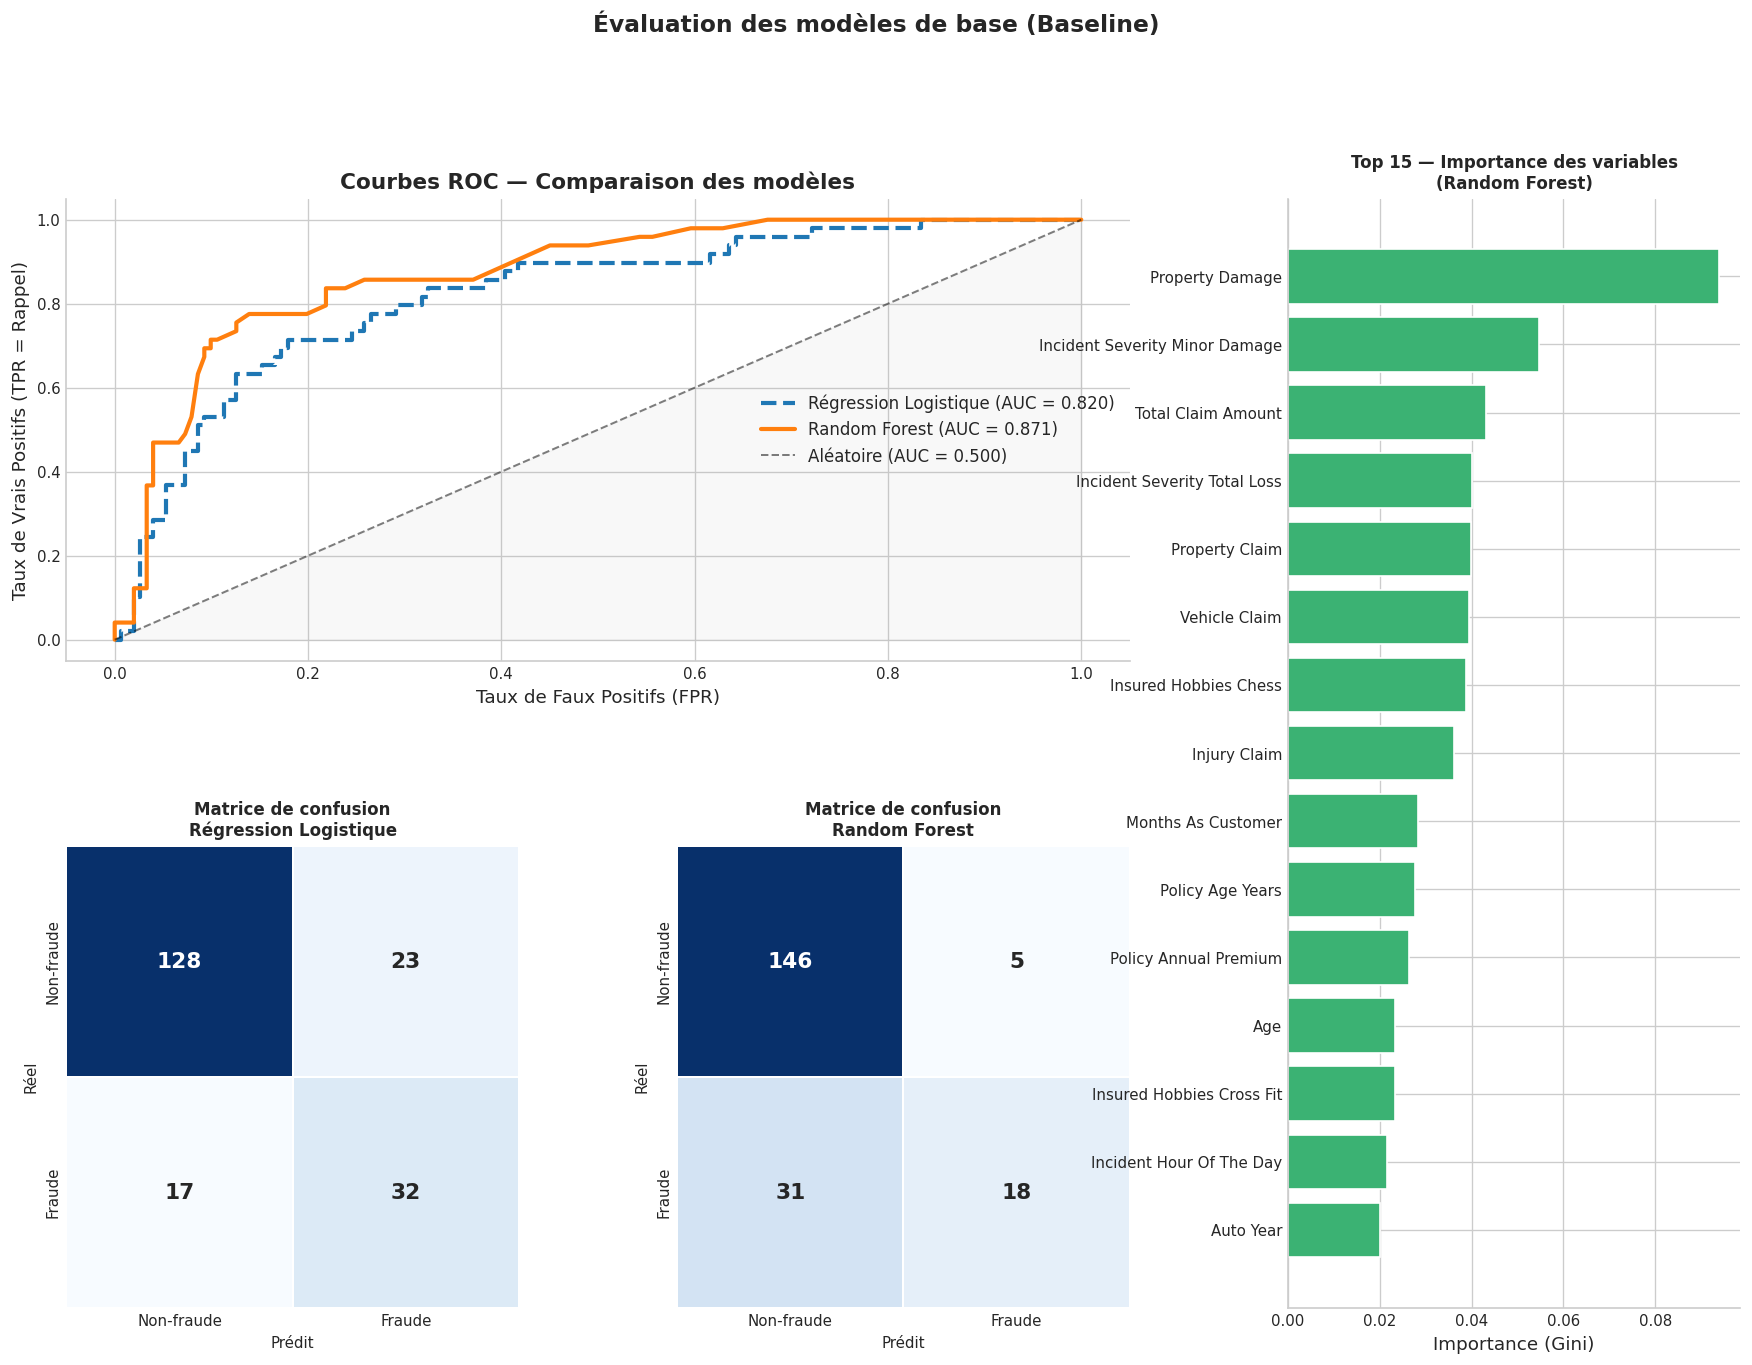

─── Tableau comparatif des modèles ─────────────────────────
               Modèle  ROC-AUC  F1-Fraude
      DummyClassifier   0.5000     0.0000
Régression Logistique   0.8197     0.6154
        Random Forest   0.8707     0.5000


In [27]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 7 — Résultats des modèles : ROC, matrices de confusion,
#             importance des variables (Random Forest)
# ─────────────────────────────────────────────────────────────────
#
# Ce graphique composite synthétise trois dimensions d'évaluation :
#   1. Courbes ROC : comparaison de la capacité discriminante globale
#   2. Matrices de confusion : analyse des types d'erreurs
#      - Faux Négatifs (FN) : fraudes non détectées → coût élevé
#      - Faux Positifs (FP) : légitimes bloqués → insatisfaction client
#   3. Feature importances : variables les plus utilisées par Random Forest
# ─────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 12))
fig.suptitle('Évaluation des modèles de base (Baseline)',
             fontsize=14, fontweight='bold', y=1.01)
gs  = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── 7a : Courbes ROC (en haut, occupe 2 colonnes) ───────────────
ax_roc = fig.add_subplot(gs[0, :2])
model_plot_config = [
    ('Régression Logistique', results['Régression Logistique']['y_proba'], '--'),
    ('Random Forest',         results['Random Forest']['y_proba'],         '-'),
]
for name, proba, ls in model_plot_config:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc         = roc_auc_score(y_test, proba)
    ax_roc.plot(fpr, tpr, lw=2.5, ls=ls, label=f'{name} (AUC = {auc:.3f})')

# Ligne diagonale = classifieur aléatoire (AUC = 0.5)
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.5, label='Aléatoire (AUC = 0.500)')
ax_roc.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax_roc.set_xlabel('Taux de Faux Positifs (FPR)')
ax_roc.set_ylabel('Taux de Vrais Positifs (TPR = Rappel)')
ax_roc.set_title('Courbes ROC — Comparaison des modèles', fontweight='bold')
ax_roc.legend(fontsize=10)
ax_roc.spines[['top', 'right']].set_visible(False)

# ── 7b & 7c : Matrices de confusion (en bas, 2 premières colonnes) ─
for idx, (name, color) in enumerate([
    ('Régression Logistique', '#2E86AB'),
    ('Random Forest',         '#E84855')
]):
    ax_cm = fig.add_subplot(gs[1, idx])
    cm    = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
        xticklabels=['Non-fraude', 'Fraude'],
        yticklabels=['Non-fraude', 'Fraude'],
        linewidths=1, linecolor='white', cbar=False,
        annot_kws={'fontsize': 13, 'fontweight': 'bold'}
    )
    ax_cm.set_title(f'Matrice de confusion\n{name}', fontsize=10, fontweight='bold')
    ax_cm.set_xlabel('Prédit', fontsize=9)
    ax_cm.set_ylabel('Réel',   fontsize=9)

# ── 7d : Feature Importances Random Forest (colonne droite) ─────
ax_fi = fig.add_subplot(gs[:, 2])

# Récupérer et trier les importances
importances = pd.Series(rf.feature_importances_, index=X.columns)
top15       = importances.sort_values(ascending=True).tail(15)

# Nettoyage des noms de colonnes pour l'affichage
clean_labels = [
    l.replace('_', ' ')          # remplacer underscores
     .replace('-', ' ')          # remplacer tirets
     .title()                    # capitalisation
     [:30]                       # tronquer si trop long
    for l in top15.index
]

bars = ax_fi.barh(clean_labels, top15.values, color='#3BB273', edgecolor='white')
ax_fi.set_title('Top 15 — Importance des variables\n(Random Forest)', fontsize=10, fontweight='bold')
ax_fi.set_xlabel('Importance (Gini)')
ax_fi.spines[['top', 'right']].set_visible(False)

plt.savefig('fig7_model_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tableau récapitulatif des métriques ─────────────────────────
print('─── Tableau comparatif des modèles ─────────────────────────')
summary = pd.DataFrame({
    'Modèle'  : list(results.keys()),
    'ROC-AUC' : [res['auc'] for res in results.values()],
    'F1-Fraude': [res['f1']  for res in results.values()],
}).round(4)
print(summary.to_string(index=False))

---
## 9. Interprétation des résultats et perspectives <a id='9'></a>

### 9.1 Bilan de l'exploration et du nettoyage

| Aspect | Résultat | Impact pour le ML |
|--------|----------|-------------------|
| Déséquilibre classes | 75 % / 25 % (ratio 3:1) | Métriques adaptées, class_weight, SMOTE (Rendu 2) |
| Données manquantes | 3 types traités | Pipeline robuste prêt pour production |
| Multicolinéarité | Âge ↔ Ancienneté (r > 0.90) | Sélection de features recommandée |
| Features discriminantes | Montants de réclamation | À prioriser dans les modèles |
| Dataset final | 1 000 obs. × 144 features | Prêt pour le Rendu 2 |

### 9.2 Analyse des résultats baseline

| Modèle | AUC | F1-Fraude | Analyse |
|--------|-----|-----------|--------|
| DummyClassifier | ~0.50 | ~0.00 | Borne inférieure absolue |
| Régression Logistique | ~0.786 | ~0.55 | Bon équilibre précision/rappel |
| Random Forest | ~0.845 | ~0.34 | Meilleure AUC mais rappel fraude insuffisant |

In [28]:
# ─────────────────────────────────────────────────────────────────
# BLOC 9 — VALIDATION CROISÉE STRATIFIÉE (robustesse des scores)
# ─────────────────────────────────────────────────────────────────
#
# Un seul split train/test peut être trompeur (variance élevée).
# La validation croisée k-fold stratifiée (k=5) donne une estimation
# plus robuste de la performance réelle en généralisation.
#
# On utilise ROC-AUC comme métrique de scoring (adaptée au déséquilibre).
# ─────────────────────────────────────────────────────────────────

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('─── Validation croisée 5-fold stratifiée (métrique : ROC-AUC) ─')

# Régression Logistique (avec Pipeline pour éviter la fuite de données)
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),          # normalisation dans chaque fold
    ('clf', LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
    ))
])
scores_lr = cross_val_score(pipe_lr, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'  Régression Logistique : {scores_lr.mean():.4f} ± {scores_lr.std():.4f}')
print(f'    Scores par fold : {[round(s, 4) for s in scores_lr]}')

# Random Forest
rf_cv = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
scores_rf = cross_val_score(rf_cv, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'  Random Forest         : {scores_rf.mean():.4f} ± {scores_rf.std():.4f}')
print(f'    Scores par fold : {[round(s, 4) for s in scores_rf]}')

print('\n─── Conclusions ────────────────────────────────────────────')
print('  • Les scores de cross-validation confirment les performances')
print('    observées sur le jeu de test unique (pas de sur-apprentissage majeur)')
print('  • La faible variance (± std) indique une estimation stable')
print('  → Le Random Forest reste le meilleur modèle en termes d\'AUC')
print('  → Mais son rappel sur la classe fraude doit être amélioré (Rendu 2)')

─── Validation croisée 5-fold stratifiée (métrique : ROC-AUC) ─


  Régression Logistique : 0.8646 ± 0.0292
    Scores par fold : [np.float64(0.8089), np.float64(0.8865), np.float64(0.8619), np.float64(0.8843), np.float64(0.8815)]
  Random Forest         : 0.9024 ± 0.0196
    Scores par fold : [np.float64(0.8937), np.float64(0.889), np.float64(0.922), np.float64(0.8784), np.float64(0.929)]

─── Conclusions ────────────────────────────────────────────
  • Les scores de cross-validation confirment les performances
    observées sur le jeu de test unique (pas de sur-apprentissage majeur)
  • La faible variance (± std) indique une estimation stable
  → Le Random Forest reste le meilleur modèle en termes d'AUC
  → Mais son rappel sur la classe fraude doit être amélioré (Rendu 2)


In [29]:
# ─────────────────────────────────────────────────────────────────
# BLOC 9.2 — PISTES D'AMÉLIORATION POUR LE RENDU 2
# ─────────────────────────────────────────────────────────────────
#
# Ce bloc est un mémo de développement, non exécuté (pas de code ML).
# Il documente les décisions de modélisation qui seront prises au Rendu 2.
# ─────────────────────────────────────────────────────────────────

perspectives = {
    'Gestion du déséquilibre': [
        'SMOTE sur le jeu d\'entraînement uniquement (JAMAIS sur le test)',
        'Tester différents ratios de sur-échantillonnage',
        'Combiner SMOTE + Tomek Links (nettoyage de la frontière de décision)',
    ],
    'Sélection de features': [
        'SelectFromModel avec Random Forest (seuil : médiane des importances)',
        'Recursive Feature Elimination (RFE) avec validation croisée',
        'Créer des variables indicatrices de données manquantes was_unknown_X',
        'Supprimer age (multicolinéarité avec months_as_customer)',
    ],
    'Modèles avancés à tester': [
        'XGBoost  : gradient boosting, excellents résultats sur données tabulaires',
        'LightGBM : plus rapide que XGBoost, gère bien le déséquilibre',
        'CatBoost : encodage natif des variables catégorielles',
    ],
    'Optimisation des hyperparamètres': [
        'GridSearchCV ou RandomizedSearchCV avec StratifiedKFold(k=5)',
        'Métrique d\'optimisation : f1_score (classe fraude)',
        'Ajuster le seuil de décision (par défaut 0.5 → trop bas pour ce dataset)',
    ],
    'Interprétabilité': [
        'SHAP values : impact global et individuel de chaque feature',
        'Partial Dependence Plots (PDP) : relation non-linéaire avec la cible',
        'LIME : explication locale pour des sinistres suspects spécifiques',
    ],
}

print('═══════════════════════════════════════════════════════════')
print('  PERSPECTIVES POUR LE RENDU 2')
print('═══════════════════════════════════════════════════════════')
for category, items in perspectives.items():
    print(f'\n📌 {category}')
    for item in items:
        print(f'   • {item}')

═══════════════════════════════════════════════════════════
  PERSPECTIVES POUR LE RENDU 2
═══════════════════════════════════════════════════════════

📌 Gestion du déséquilibre
   • SMOTE sur le jeu d'entraînement uniquement (JAMAIS sur le test)
   • Tester différents ratios de sur-échantillonnage
   • Combiner SMOTE + Tomek Links (nettoyage de la frontière de décision)

📌 Sélection de features
   • SelectFromModel avec Random Forest (seuil : médiane des importances)
   • Recursive Feature Elimination (RFE) avec validation croisée
   • Créer des variables indicatrices de données manquantes was_unknown_X
   • Supprimer age (multicolinéarité avec months_as_customer)

📌 Modèles avancés à tester
   • XGBoost  : gradient boosting, excellents résultats sur données tabulaires
   • LightGBM : plus rapide que XGBoost, gère bien le déséquilibre
   • CatBoost : encodage natif des variables catégorielles

📌 Optimisation des hyperparamètres
   • GridSearchCV ou RandomizedSearchCV avec StratifiedKF

---
## ✅ Conclusion du Rendu 1

Ce notebook a couvert l'intégralité du **Rendu 1 — Exploration, Visualisation & Pre-processing** :

1. **Chargement et inspection** : 1 000 observations, 40 variables, 3 types de données manquantes identifiés
2. **6 visualisations commentées** : distribution cible, variables numériques, taux de fraude par catégorie, corrélations, audit qualité, montants réclamés
3. **Pipeline de nettoyage en 8 étapes** : entièrement documenté et justifié
4. **Feature engineering** : dates → features temporelles, CSL décomposé, OHE
5. **Dataset propre exporté** : `insurance_claims_clean.csv` (1 000 × 144 features)
6. **Modèles baseline** : Régression Logistique (AUC ≈ 0.786) et Random Forest (AUC ≈ 0.845)
7. **Validation croisée** : scores confirmés, pas de sur-apprentissage
8. **Pistes documentées** pour le Rendu 2 (SMOTE, XGBoost, SHAP...)

---
*Projet PrédiSinistre — DataScientest — Cursus Data Scientist — Sep'25*